In [7]:
# importing needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:

#read in Central Valley csvs from external drive
#path1 = '/Volumes/disk1/Central Valley Fog/4205333.csv'
#path2 = '/Volumes/disk1/Central Valley Fog/4206426.csv'
#path3 = '/Volumes/disk1/Central Valley Fog/4206427.csv'
path1 = 'E:/Central Valley Fog/4205333.csv'
path2 = 'E:/Central Valley Fog/4206426.csv'
path3 = 'E:/Central Valley Fog/4206427.csv'


#df1 = pd.read_csv(path1, usecols=['STATION', 'DATE', 'HourlyPrecipitation', 'HourlyRelativeHumidity', 'HourlyVisibility'])
#df2 = pd.read_csv(path2, usecols=['STATION', 'DATE', 'HourlyPrecipitation', 'HourlyRelativeHumidity', 'HourlyVisibility'])
#df3 = pd.read_csv(path3, usecols=['STATION', 'DATE', 'HourlyPrecipitation', 'HourlyRelativeHumidity', 'HourlyVisibility'])

#df1 = pd.read_csv(path1, usecols=[0, 5, 42, 46, 50])
#df2 = pd.read_csv(path2, usecols=[0, 5, 42, 46, 50])  
#df3 = pd.read_csv(path3, usecols=[0, 5, 42, 46, 50])

In [9]:
df1 = pd.read_csv(path1, usecols=['STATION', 'DATE', 'HourlyVisibility','HourlyPrecipitation'],low_memory=False)
df2 = pd.read_csv(path2, usecols=['STATION', 'DATE', 'HourlyVisibility','HourlyPrecipitation'],low_memory=False)
df3 = pd.read_csv(path3, usecols=['STATION', 'DATE', 'HourlyVisibility','HourlyPrecipitation'],low_memory=False)


In [10]:
df1.head()

,STATION,DATE,HourlyPrecipitation,HourlyVisibility
0,USW00093210,1998-06-13T00:00:00,NaN,NaN
1,USW00093210,1998-06-15T00:00:00,NaN,NaN
2,USW00093210,1998-06-16T00:00:00,NaN,NaN
3,USW00093210,1998-06-17T00:00:00,NaN,NaN
4,USW00093210,1998-06-18T00:00:00,NaN,NaN


In [11]:
# print all column names
for col in df1.columns:
    print(col)

STATION
DATE
HourlyPrecipitation
HourlyVisibility


In [12]:
df_list = [df1, df2, df3] 

CV_data = pd.concat(df_list, ignore_index = True)

print(CV_data.head(5))

       STATION                 DATE HourlyPrecipitation HourlyVisibility
0  USW00093210  1998-06-13T00:00:00                 NaN              NaN
1  USW00093210  1998-06-15T00:00:00                 NaN              NaN
2  USW00093210  1998-06-16T00:00:00                 NaN              NaN
3  USW00093210  1998-06-17T00:00:00                 NaN              NaN
4  USW00093210  1998-06-18T00:00:00                 NaN              NaN


In [13]:
# select rows where all columns are not null
CV_rows = CV_data[CV_data.notna().all(axis=1)]
print(CV_rows)

              STATION                 DATE HourlyPrecipitation  \
53944     USW00093210  2004-12-31T16:53:00                 1.5   
53945     USW00093210  2004-12-31T17:38:00                 0.3   
53946     USW00093210  2004-12-31T17:53:00                 0.3   
53947     USW00093210  2004-12-31T18:26:00                 0.5   
53948     USW00093210  2004-12-31T18:44:00                 2.0   
...               ...                  ...                 ...   
16275879  USW00023167  2025-12-26T02:55:00                 0.2   
16275882  USW00023167  2025-12-26T03:55:00                 1.0   
16275885  USW00023167  2025-12-26T04:55:00                 2.5   
16275888  USW00023167  2025-12-26T05:55:00                 0.2   
16276267  USW00023167  2025-12-31T15:55:00                 0.2   

         HourlyVisibility  
53944              16.093  
53945              16.093  
53946              16.093  
53947               9.656  
53948               8.047  
...                   ...  
16275879   

In [14]:
# convert date column to datetime format
CV_rows["DATE"] = pd.to_datetime(CV_rows["DATE"])

In [15]:
# extract year and month from date column and add as new columns
CV_rows["year"] = CV_rows["DATE"].dt.year
CV_rows["month"] = CV_rows["DATE"].dt.month
CV_rows["day"] = CV_rows["DATE"].dt.day
CV_rows["hour"] = CV_rows["DATE"].dt.hour
CV_rows["minute"] = CV_rows["DATE"].dt.minute
print(CV_rows.head(5))

           STATION                DATE HourlyPrecipitation HourlyVisibility  \
53944  USW00093210 2004-12-31 16:53:00                 1.5           16.093   
53945  USW00093210 2004-12-31 17:38:00                 0.3           16.093   
53946  USW00093210 2004-12-31 17:53:00                 0.3           16.093   
53947  USW00093210 2004-12-31 18:26:00                 0.5            9.656   
53948  USW00093210 2004-12-31 18:44:00                 2.0            8.047   

       year  month  day  hour  minute  
53944  2004     12   31    16      53  
53945  2004     12   31    17      38  
53946  2004     12   31    17      53  
53947  2004     12   31    18      26  
53948  2004     12   31    18      44  


In [16]:
# convert hourly precipitation and visibility to numeric values
CV_rows["HourlyPrecipitation"] = pd.to_numeric(CV_rows["HourlyPrecipitation"], errors='coerce')
CV_rows["HourlyVisibility"] = pd.to_numeric(CV_rows["HourlyVisibility"], errors='coerce')

In [17]:
# make dataframe with only columns where precipitation is less than 0.03
CV_precip_rows = CV_rows[CV_rows['HourlyPrecipitation'] < 0.03]

In [18]:
CV_precip_rows.head()

,STATION,DATE,HourlyPrecipitation,HourlyVisibility,year,month,day,hour,minute
53956,USW00093210,2004-12-31 22:53:00,0.0,16.093,2004,12,31,22,53
53963,USW00093210,2005-01-01 00:53:00,0.0,16.093,2005,1,1,0,53
53965,USW00093210,2005-01-01 01:53:00,0.0,16.093,2005,1,1,1,53
53966,USW00093210,2005-01-01 02:53:00,0.0,16.093,2005,1,1,2,53
53967,USW00093210,2005-01-01 03:53:00,0.0,16.093,2005,1,1,3,53


In [19]:
# make dataframe with only columns where visibility is less than 1 km
CV_fog_rows = CV_rows[CV_rows['HourlyVisibility'] < 1.0]

In [20]:
CV_fog_rows['HourlyPrecipitation'] = CV_fog_rows['HourlyPrecipitation'].fillna(0)
print(CV_fog_rows)

              STATION                DATE  HourlyPrecipitation  \
54139     USW00093210 2005-01-06 03:53:00                  0.0   
54140     USW00093210 2005-01-06 04:53:00                  0.0   
54142     USW00093210 2005-01-06 05:53:00                  0.0   
54143     USW00093210 2005-01-06 06:53:00                  0.0   
54144     USW00093210 2005-01-06 07:53:00                  0.0   
...               ...                 ...                  ...   
15979491  USW00093216 2025-12-31 03:55:00                  0.0   
15979495  USW00093216 2025-12-31 04:55:00                  0.0   
15979499  USW00093216 2025-12-31 06:55:00                  0.0   
16243343  USW00023167 2023-12-22 05:55:00                  0.2   
16271421  USW00023167 2025-10-23 07:55:00                  0.2   

          HourlyVisibility  year  month  day  hour  minute  
54139                0.402  2005      1    6     3      53  
54140                0.402  2005      1    6     4      53  
54142                0.4

In [21]:
#get unique station names
unique_names = CV_fog_rows['STATION'].unique()
names_df = pd.DataFrame(unique_names)
print(unique_names)
print(names_df)

<StringArray>
['USW00093210', 'USW00024216', 'USW00093203', 'USW00024257', 'USW00023131',
 'USW00023206', 'USW00023182', 'USW00023208', 'USW00023258', 'USW00000479',
 'USW00093144', 'USW00023237', 'USW00093225', 'USW00023232', 'USW00093205',
 'USW00023161', 'USW00093193', 'USW00003159', 'USW00023203', 'USW00023114',
 'USW00023202', 'USW00023155', 'USW00023110', 'USW00093216', 'USW00023167']
Length: 25, dtype: str
              0
0   USW00093210
1   USW00024216
2   USW00093203
3   USW00024257
4   USW00023131
5   USW00023206
6   USW00023182
7   USW00023208
8   USW00023258
9   USW00000479
10  USW00093144
11  USW00023237
12  USW00093225
13  USW00023232
14  USW00093205
15  USW00023161
16  USW00093193
17  USW00003159
18  USW00023203
19  USW00023114
20  USW00023202
21  USW00023155
22  USW00023110
23  USW00093216
24  USW00023167


In [22]:
#count how many foggy hours per year for each station
foghrs_per_station = CV_fog_rows.groupby(['STATION', 'year']).size()
print(foghrs_per_station)

STATION      year
USW00000479  2014     18
             2015     23
             2016     49
             2017     36
             2018     19
                    ... 
USW00093225  2021    236
             2022    178
             2023     64
             2024     97
             2025     30
Length: 601, dtype: int64


In [23]:
print(foghrs_per_station['STATION'])

KeyError: 'STATION'

In [ ]:
#iterate through unique names and plot foggy hours per year for each station
for i in unique_names:(foghrs_per_station['STATION'] == i
    foghrs_per_station.loc[)].plot(figsize=(15,4), kind = 'bar')
    plt.title(i, fontsize=18) #Labeling title
    plt.xlabel('years', fontsize=12) #Labeling x-axis 
    plt.ylabel('station fog days', fontsize=12) #Labeling y-axis
plt.show()

KeyError: 'STATION'

In [80]:
# Iterate through unique values and plot on respective axes
for i in unique_names:
    foghrs_per_station.loc[(foghrs_per_station['STATION'] == i)].plot(figsize=(15,4), kind = 'bar')
    plt.title(i, fontsize=18) #Labeling title
    plt.xlabel('years', fontsize=12) #Labeling x-axis 
    plt.ylabel('station fog days', fontsize=12) #Labeling y-axis 

plt.show()

AttributeError: 'list' object has no attribute 'loc'

<Axes: xlabel='STATION,year'>

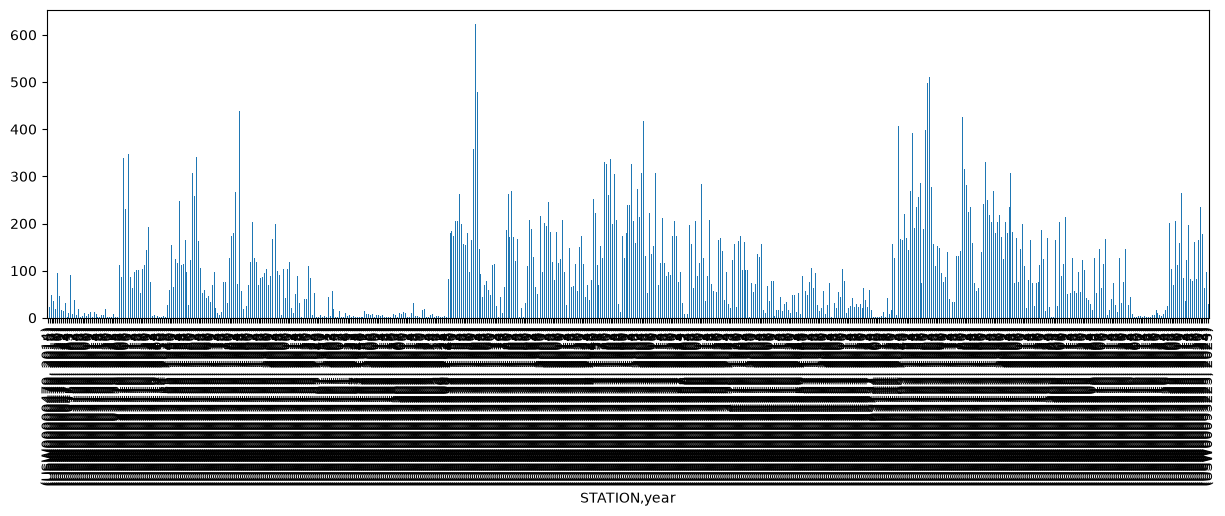

In [69]:
#plot foggy hours per year for each station per year
foghrs_per_station.plot(kind='bar', figsize=(15,4))

c:\Users\Work Account\miniconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:599: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=self.figsize)


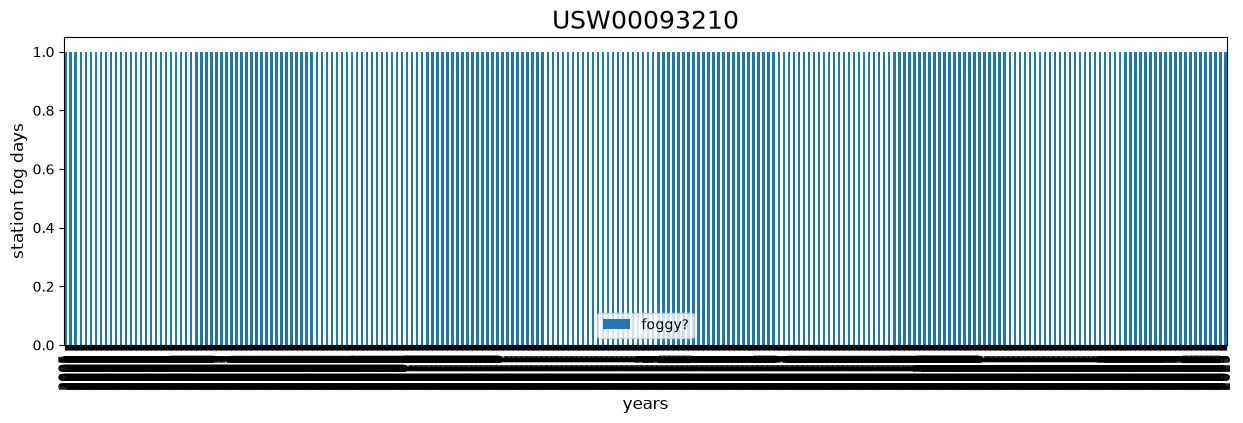

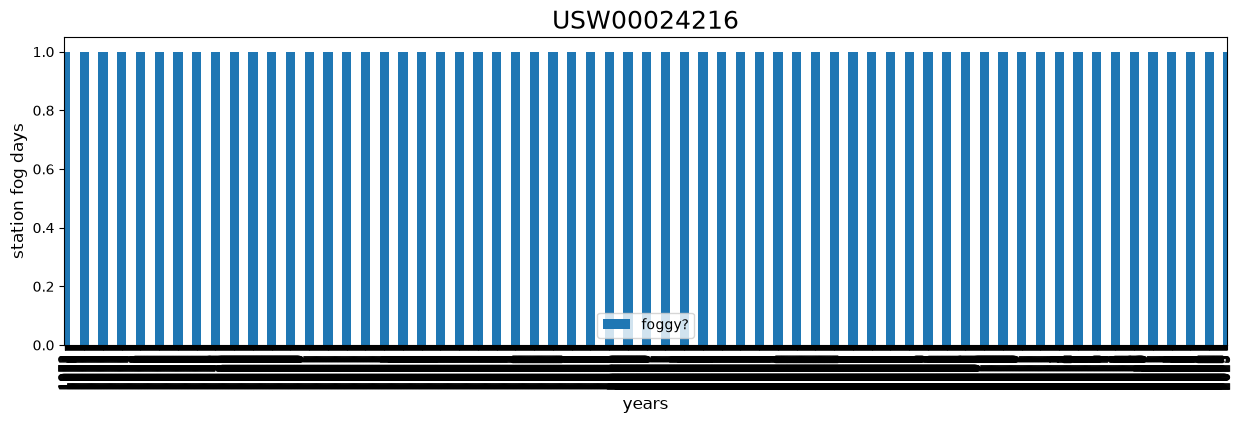

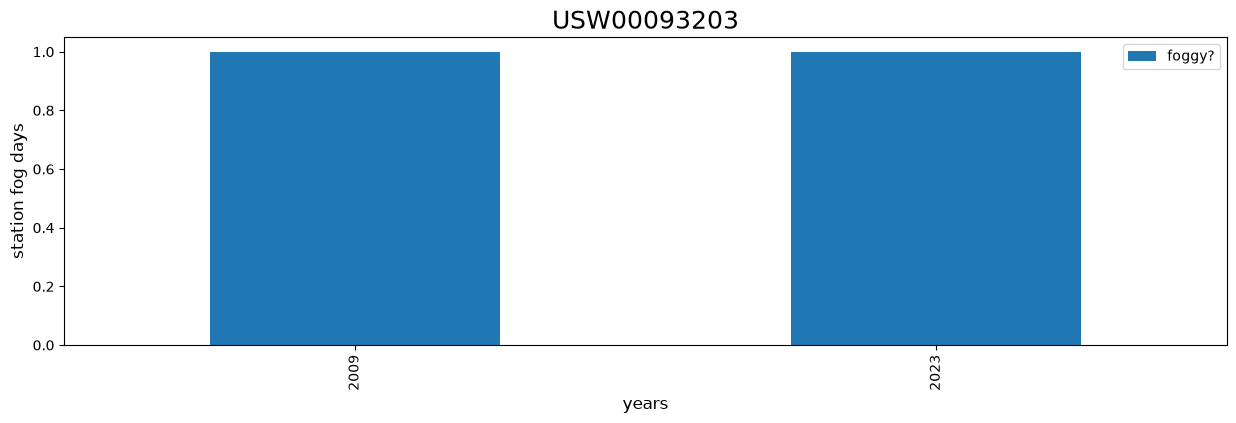

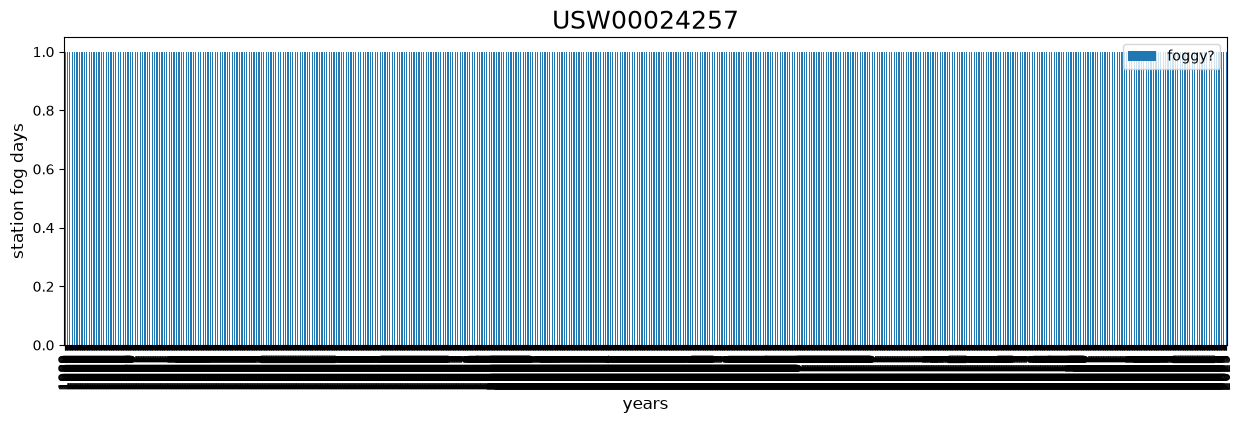

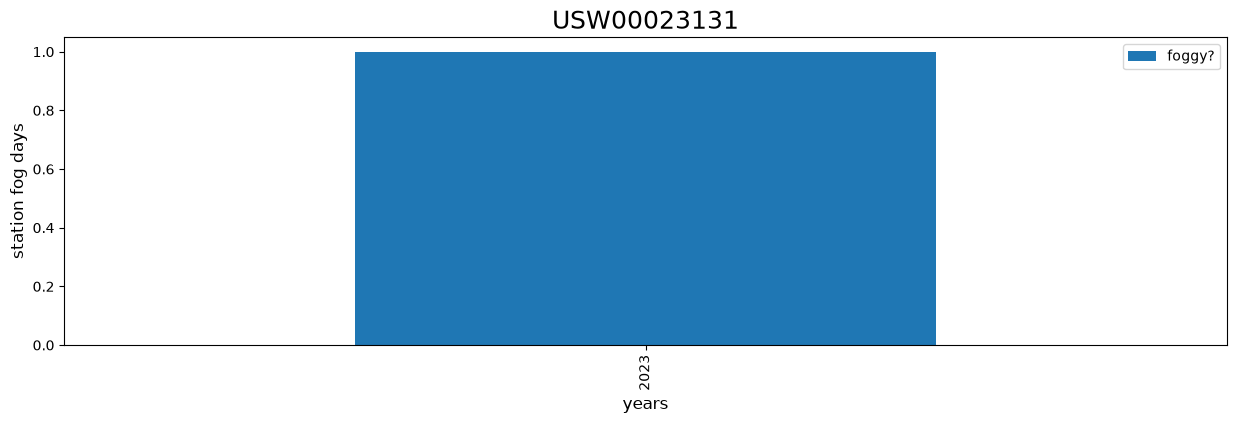

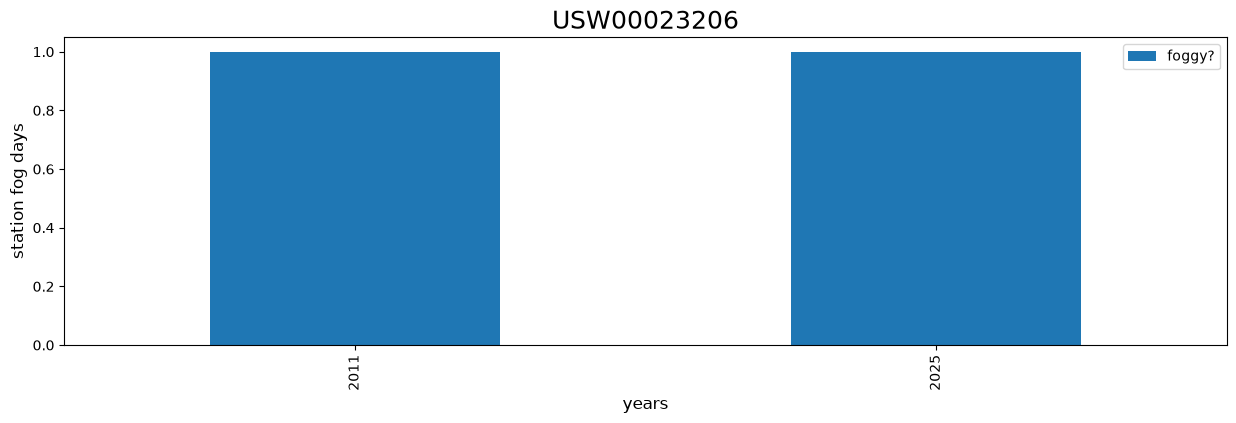

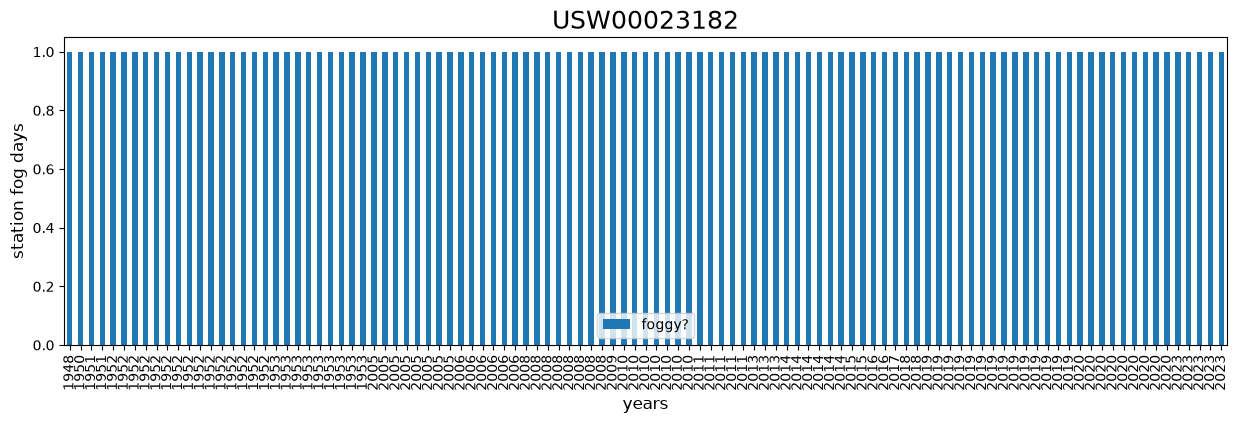

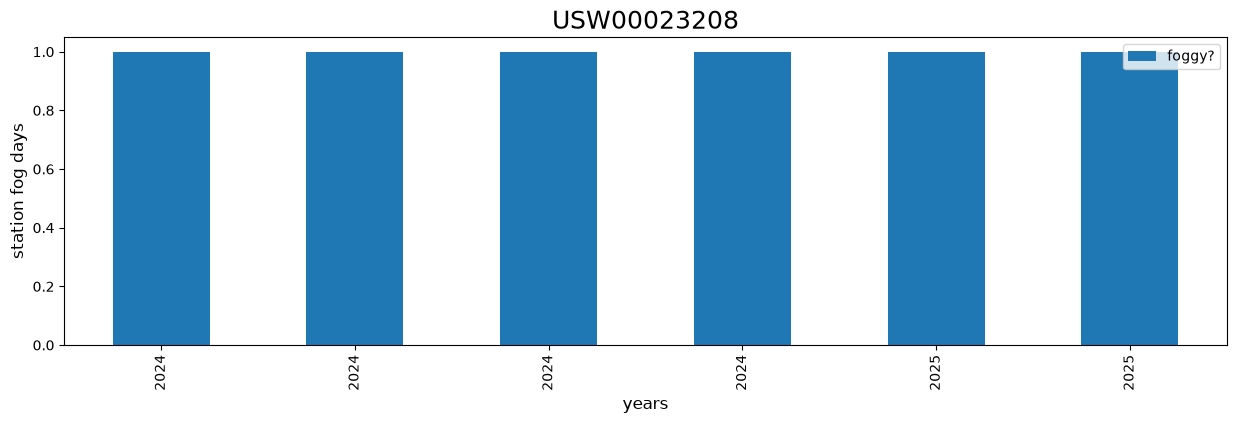

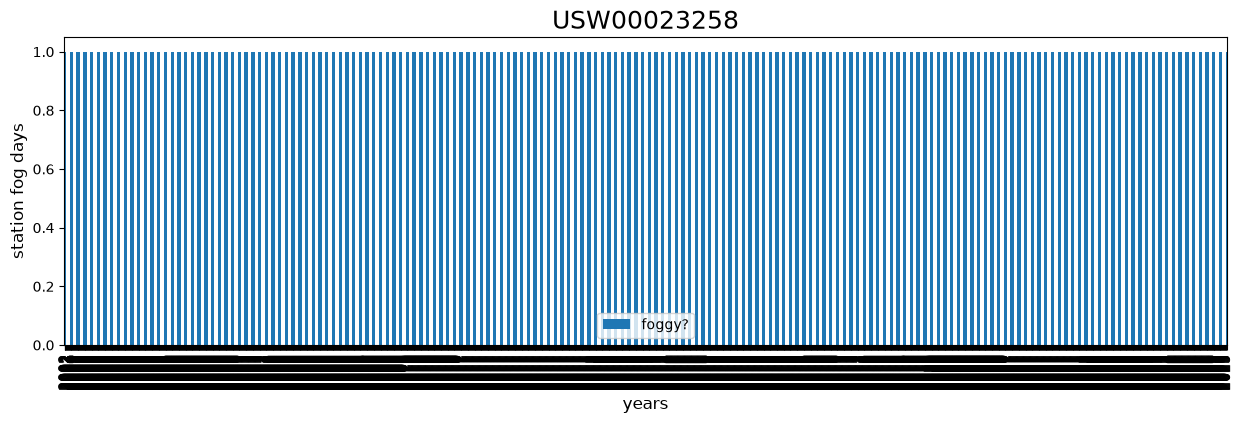

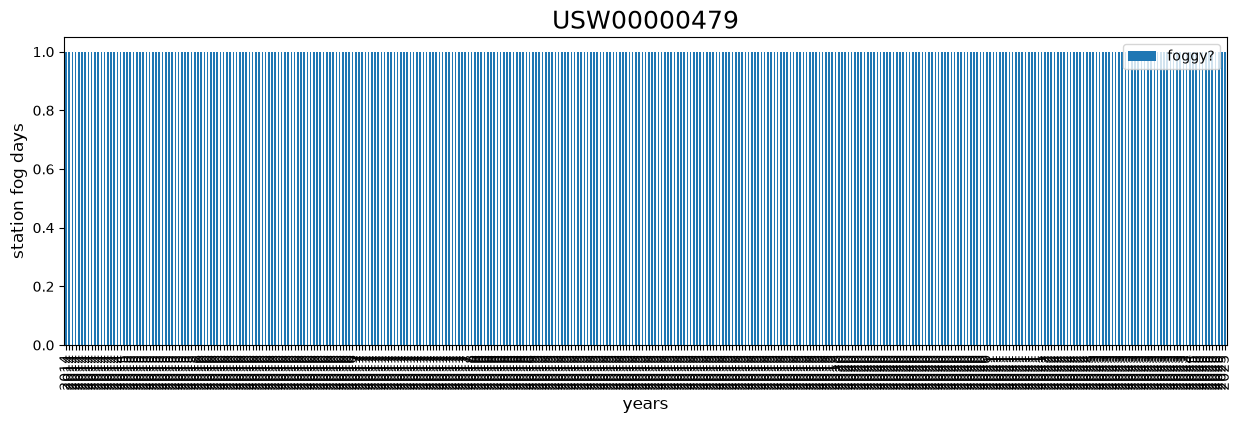

KeyboardInterrupt: 

In [60]:
# Create subplots dynamically
# fig, axs = plt.subplots(1, len(unique_names),  sharey=True)

# Iterate through unique values and plot on respective axes
for i in unique_names:
    CV_fog_rows.loc[(CV_fog_rows['STATION'] == i)].plot(x='year',y="foggy?", figsize=(15,4), kind = 'bar')
    plt.title(i, fontsize=18) #Labeling title
    plt.xlabel('years', fontsize=12) #Labeling x-axis 
    plt.ylabel('station fog days', fontsize=12) #Labeling y-axis 

plt.show()

In [17]:
unique_station_total_fog_days = CVtotal_fog_rows.groupby(['STATION'])['year'].sum().rename('station_fog_days_total').reset_index()
print(unique_station_total_fog_days)

        STATION  station_fog_days_total
0   USW00003159                   69891
1   USW00023110                   81568
2   USW00023155                  119670
3   USW00023161                   33901
4   USW00023182                   38011
5   USW00023232                  121695
6   USW00023237                  109744
7   USW00023258                   54324
8   USW00023271                    2020
9   USW00024216                  111692
10  USW00024257                   80220
11  USW00093193                  119682
12  USW00093205                   38304
13  USW00093210                   32251
14  USW00093225                   38289


Text(0.5, 1.0, 'Central Valley station counts of number of days with heavy fog')

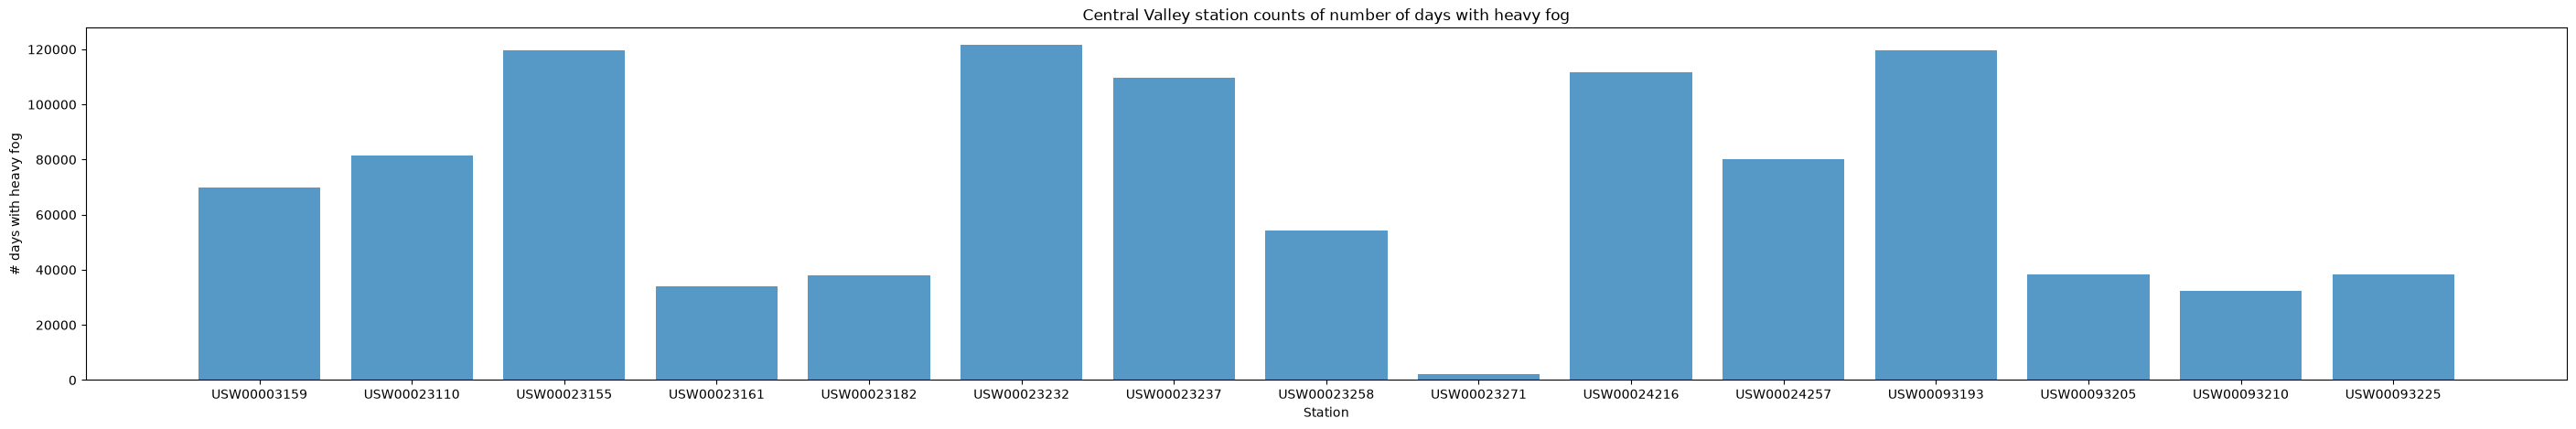

In [18]:
# plot which stations have most heavy fog days to date
fig1, ax1 = plt.subplots(figsize=(35,5))

br1 = ax1.bar(
    unique_station_total_fog_days["STATION"],
    unique_station_total_fog_days["station_fog_days_total"],
    alpha=0.75
)
# Set customizations
ax1.set_xlabel("Station")
ax1.set_ylabel("# days with heavy fog")
ax1.set_title("Central Valley station counts of number of days with heavy fog")


#Gives which stations have the most fog measurements to date. 

In [19]:
# make a list of years with data
years_c = CVtotal_fog_rows['year'].unique()
years_considered = sorted(years_c)
print(years_considered)

[np.int32(1965), np.int32(1966), np.int32(1967), np.int32(1968), np.int32(1969), np.int32(1970), np.int32(1971), np.int32(1972), np.int32(1973), np.int32(1974), np.int32(1975), np.int32(1976), np.int32(1977), np.int32(1978), np.int32(1979), np.int32(1980), np.int32(1981), np.int32(1982), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


c:\Users\Work Account\miniconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:599: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=self.figsize)


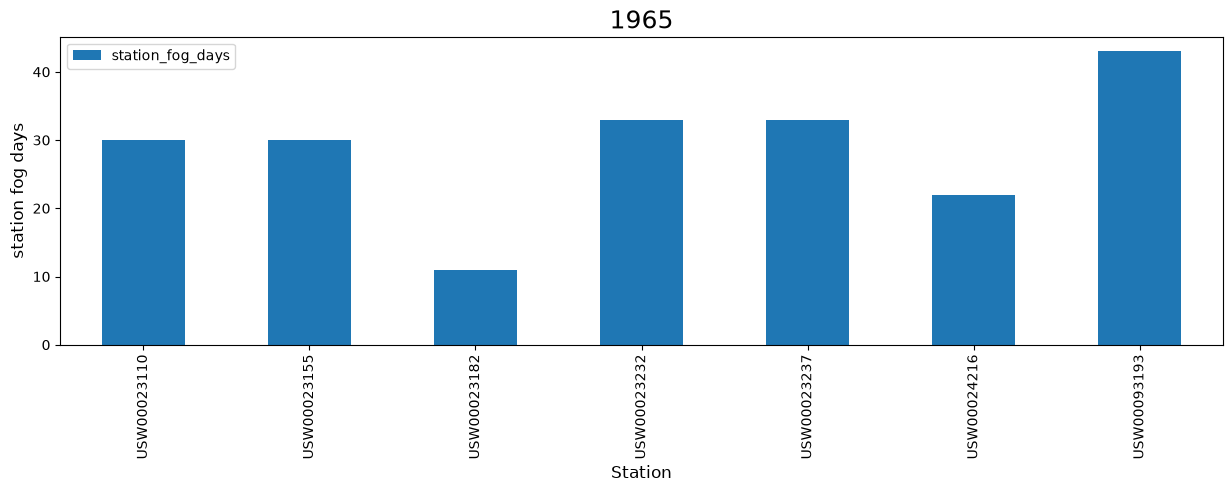

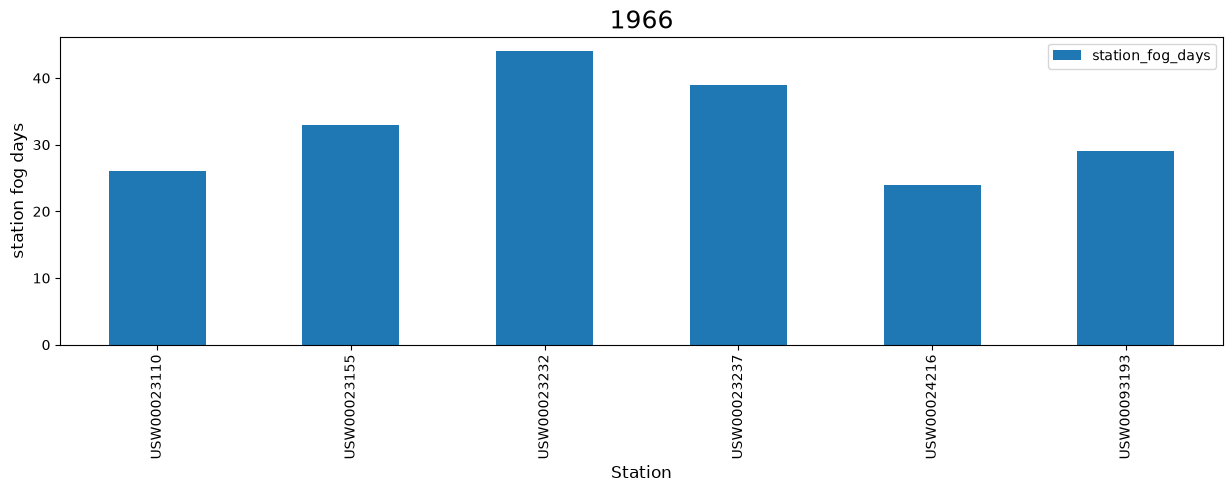

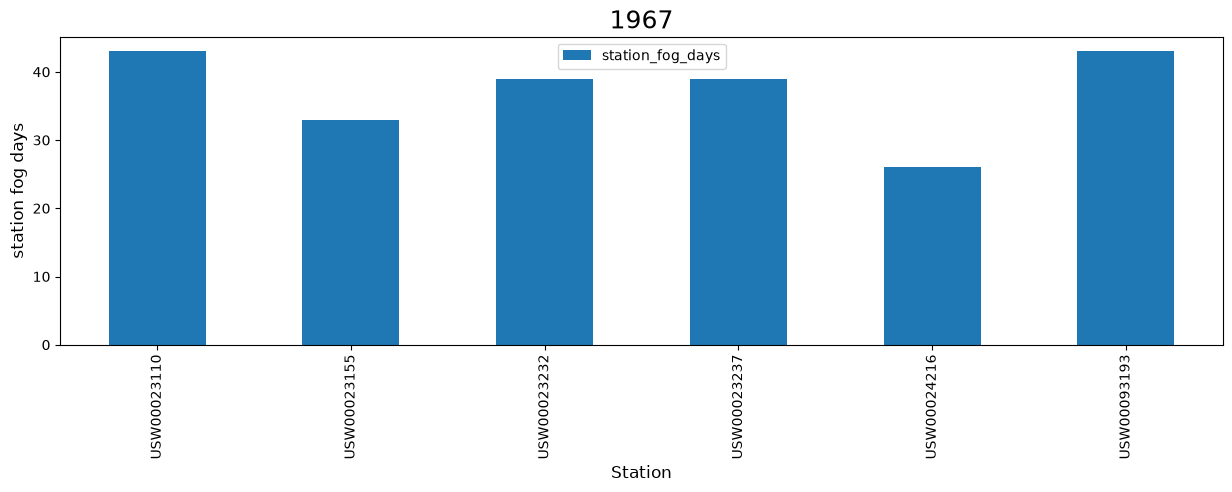

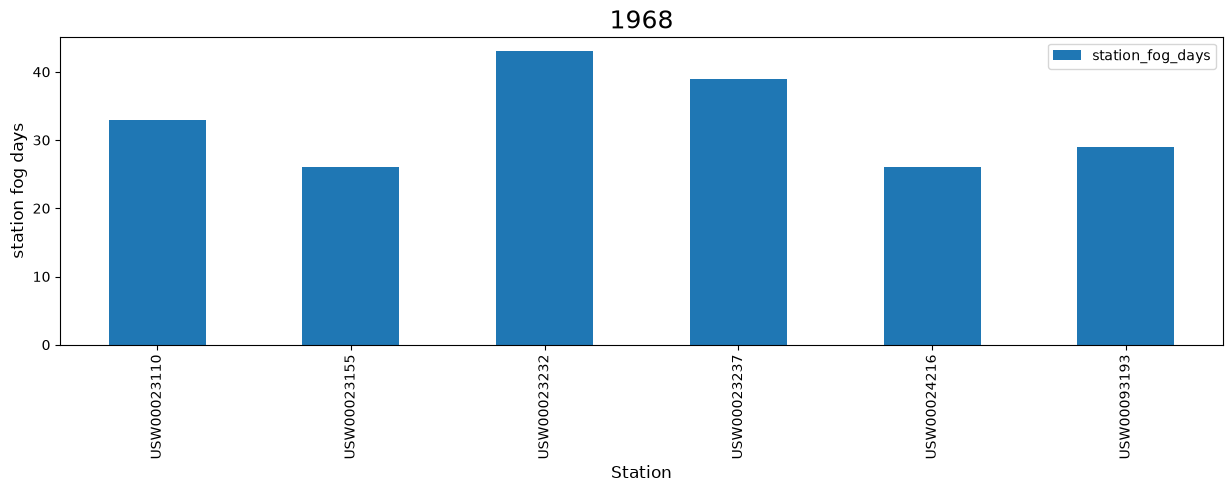

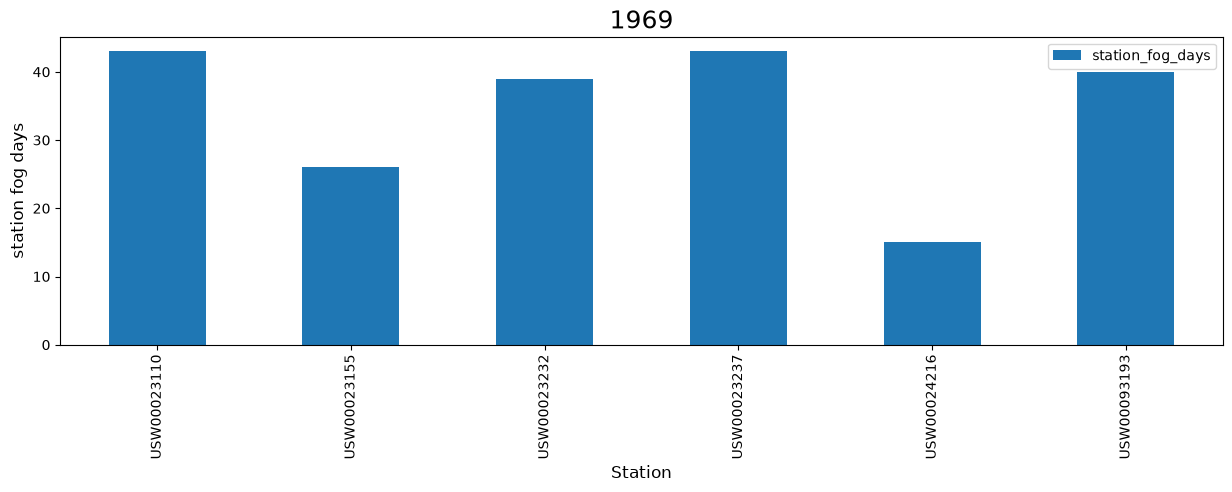

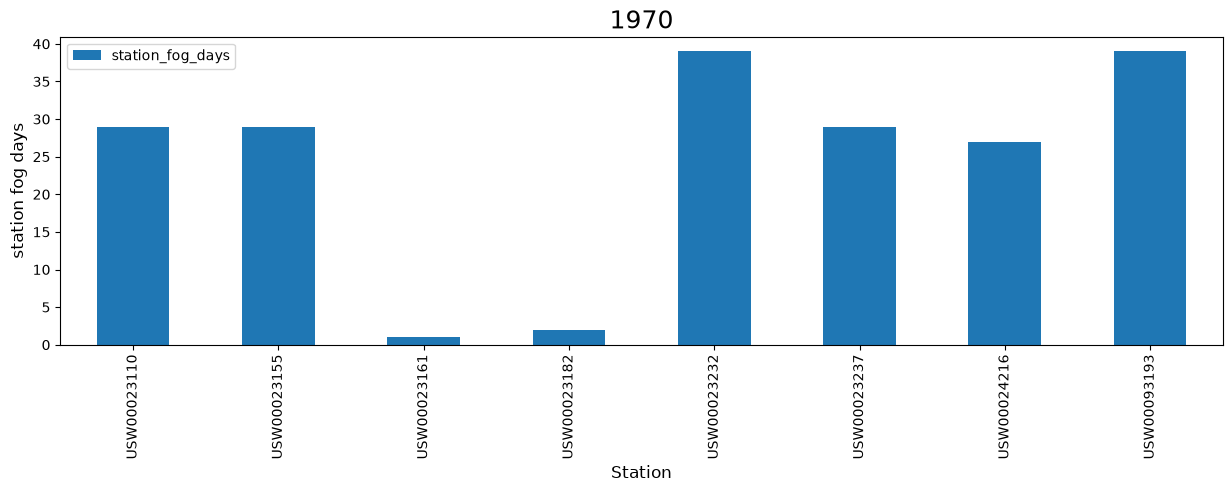

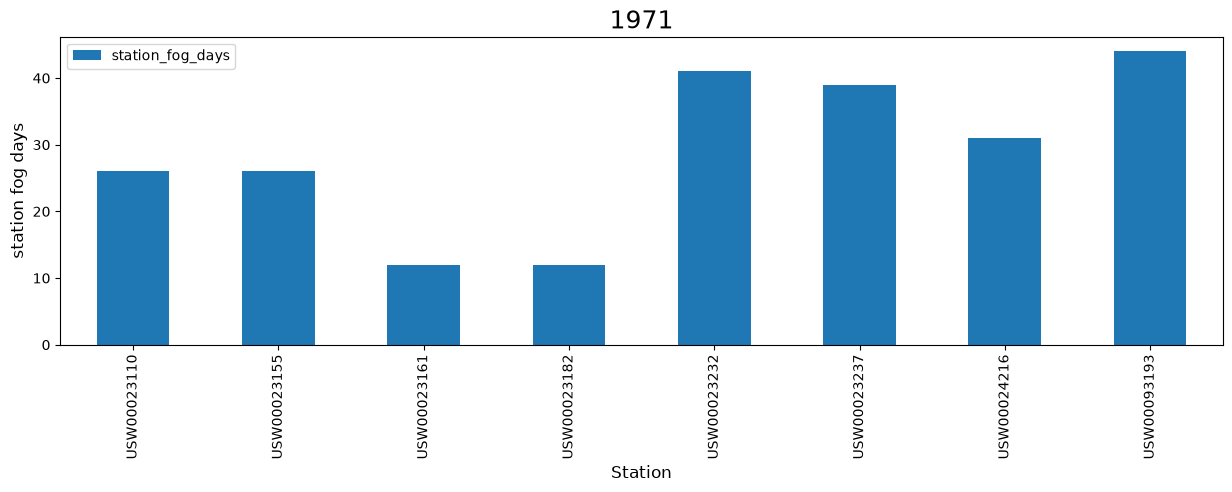

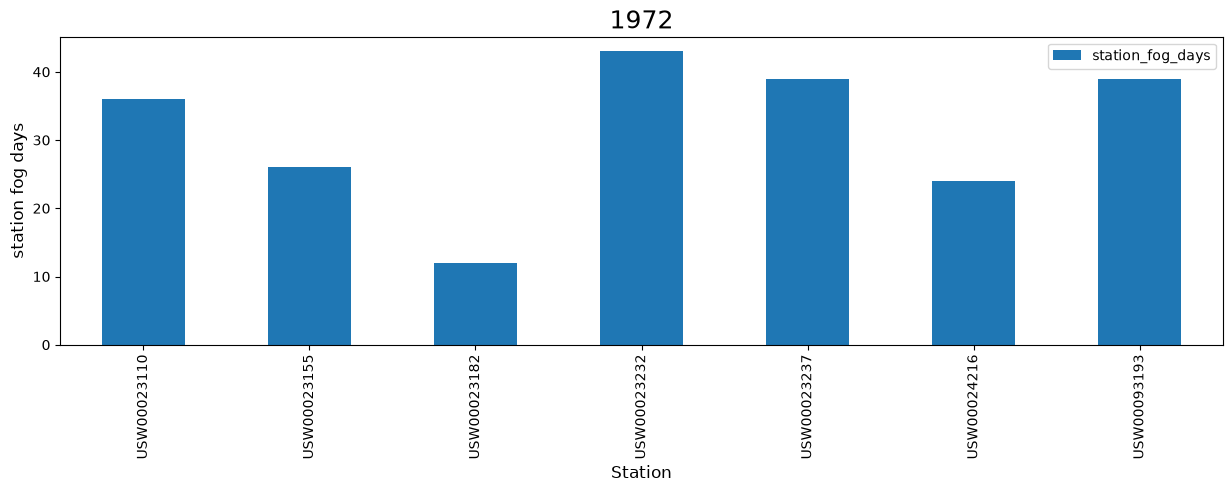

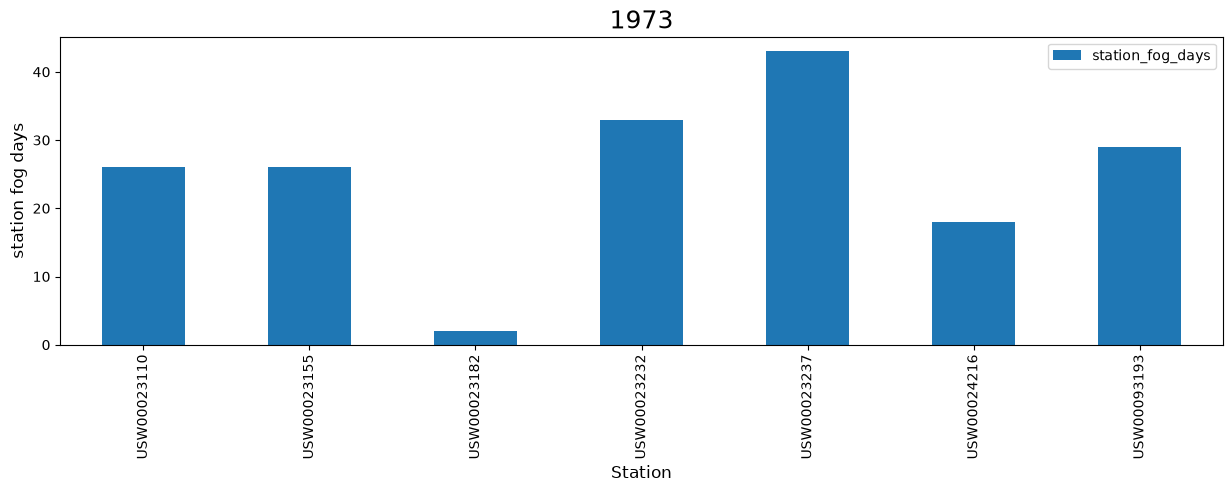

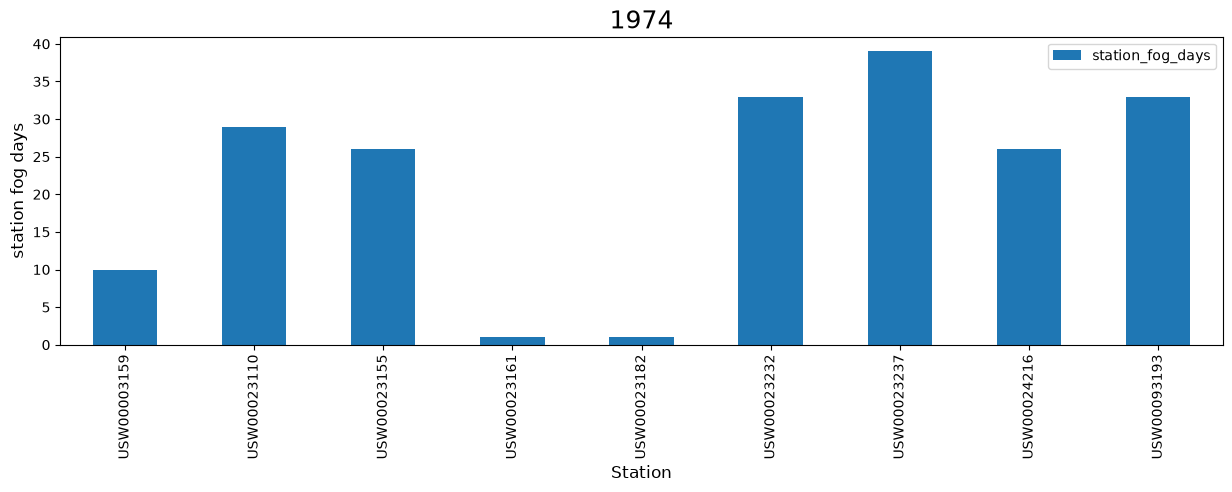

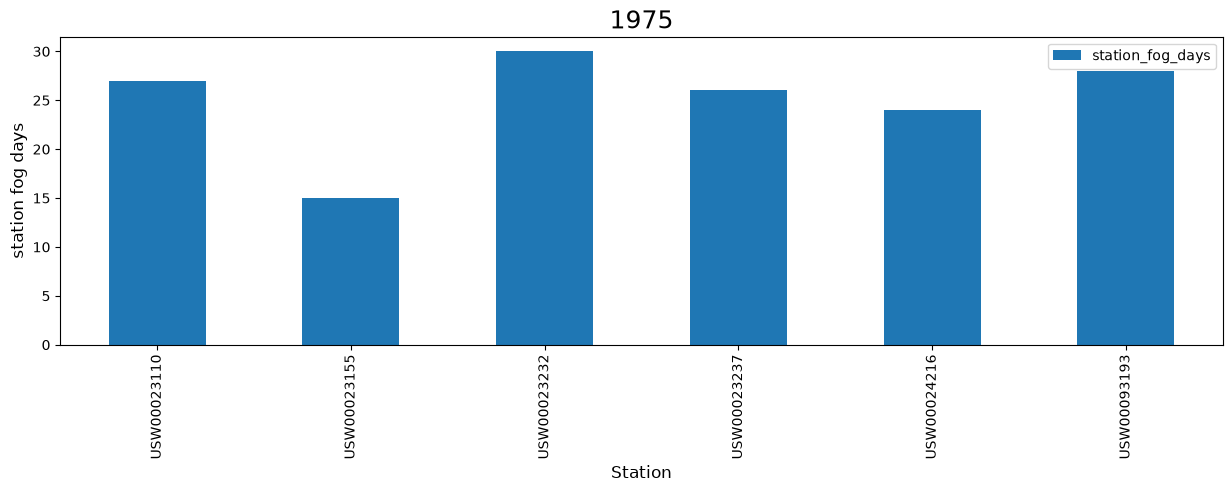

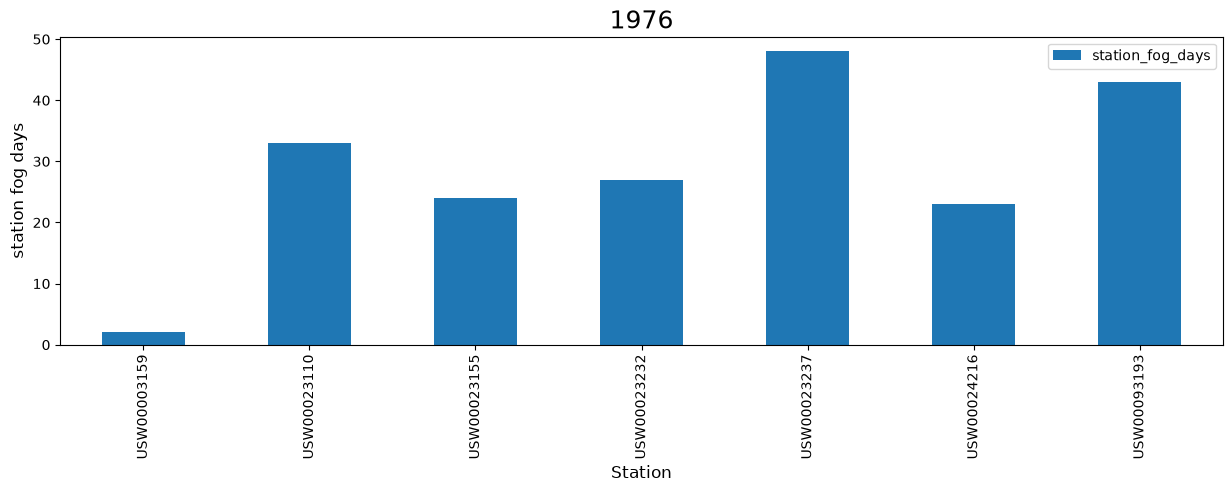

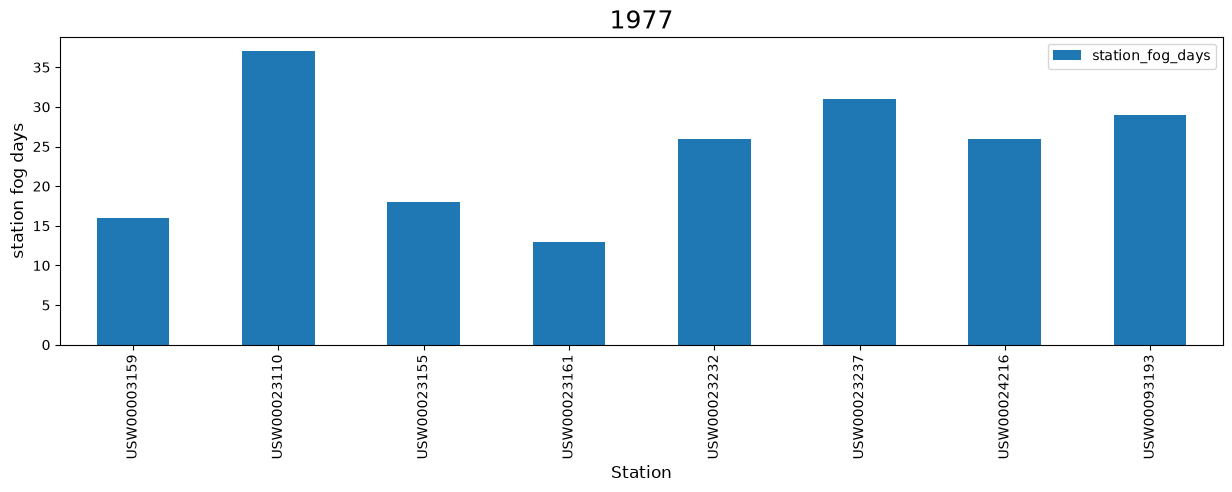

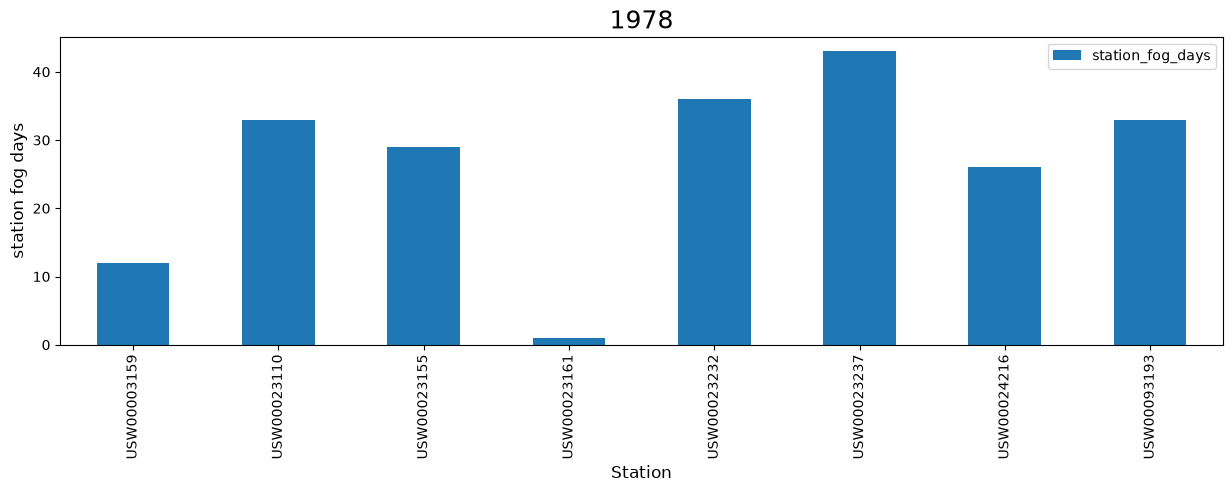

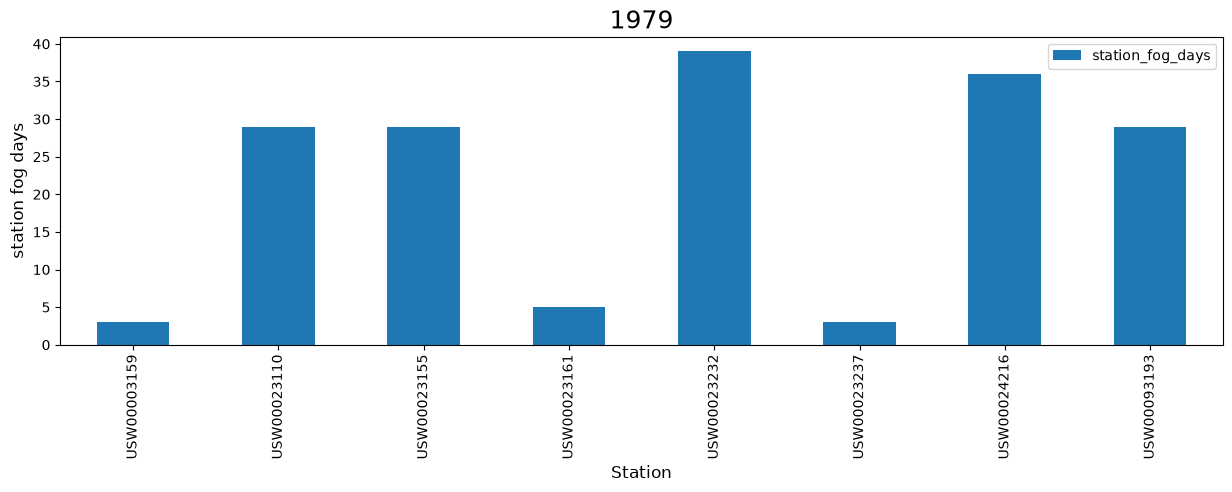

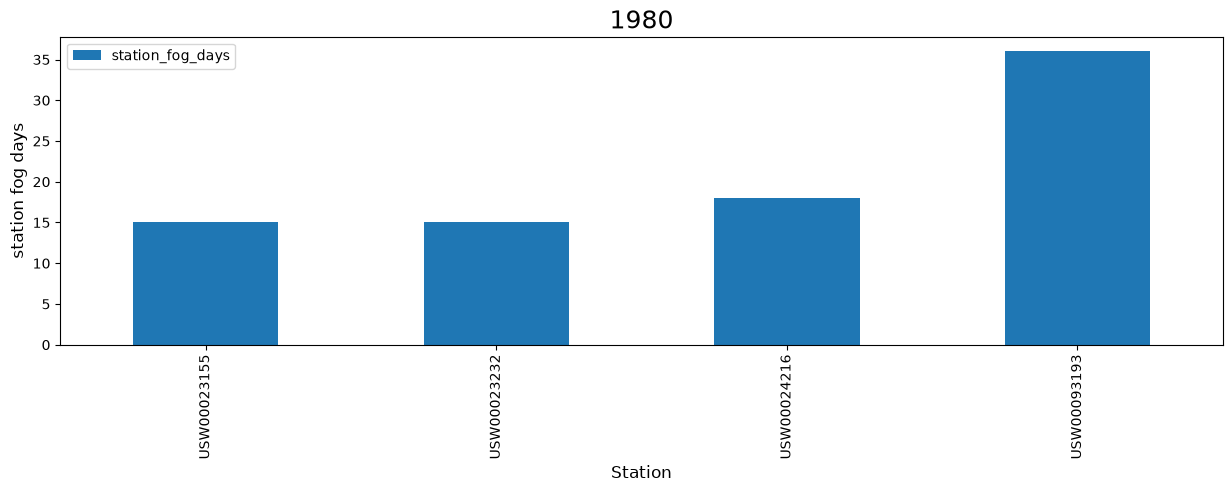

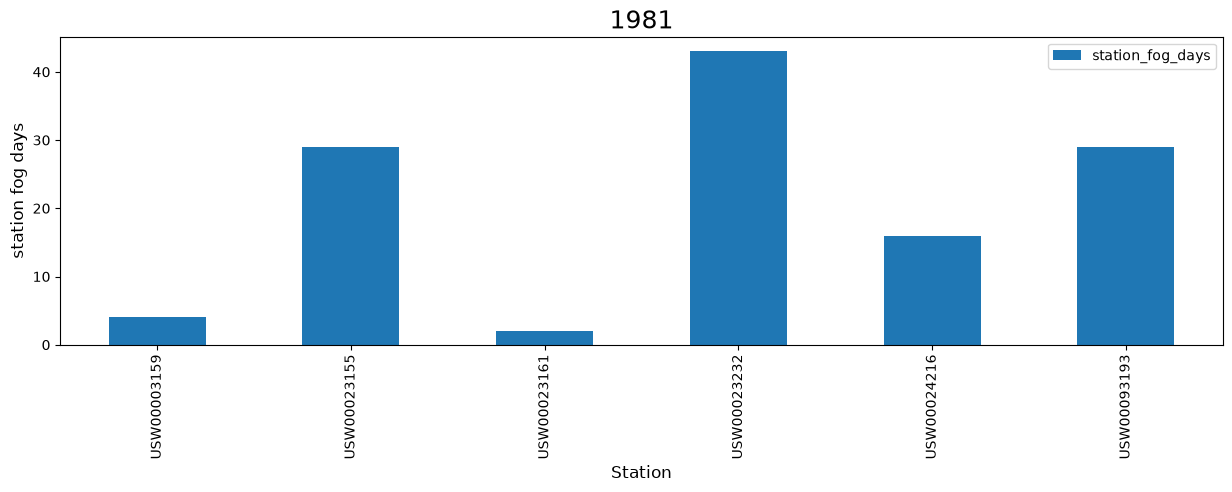

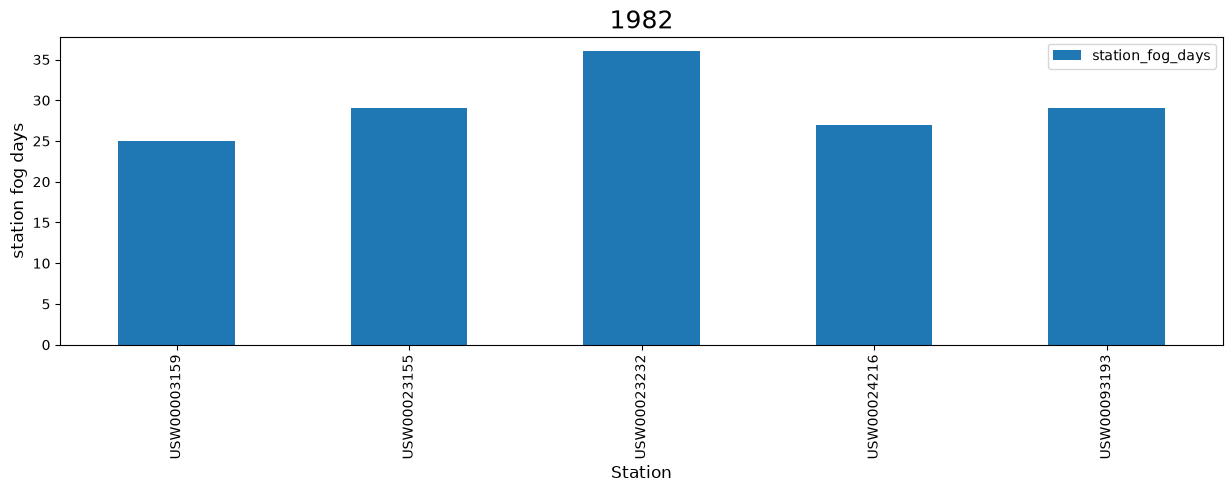

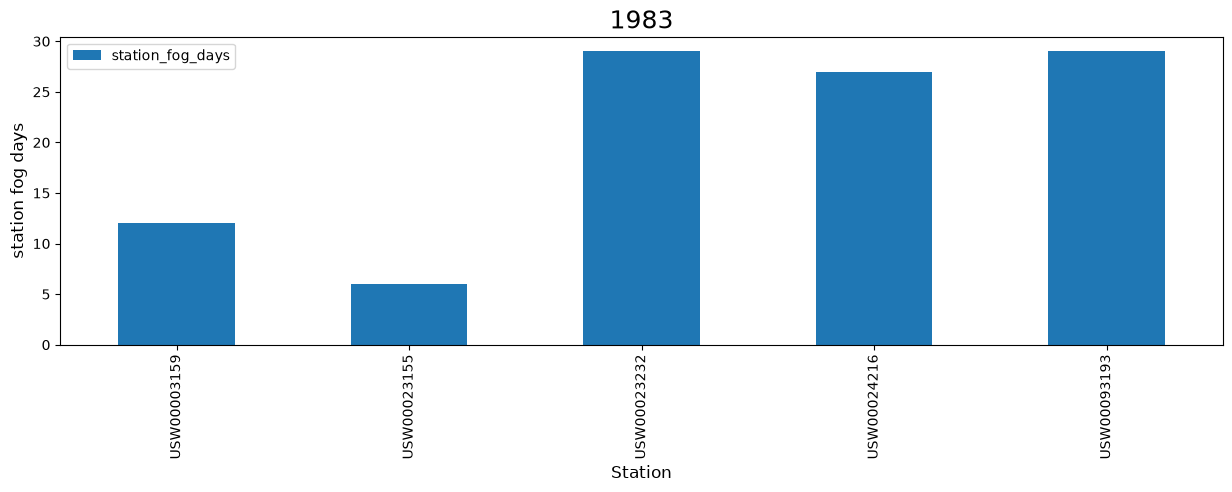

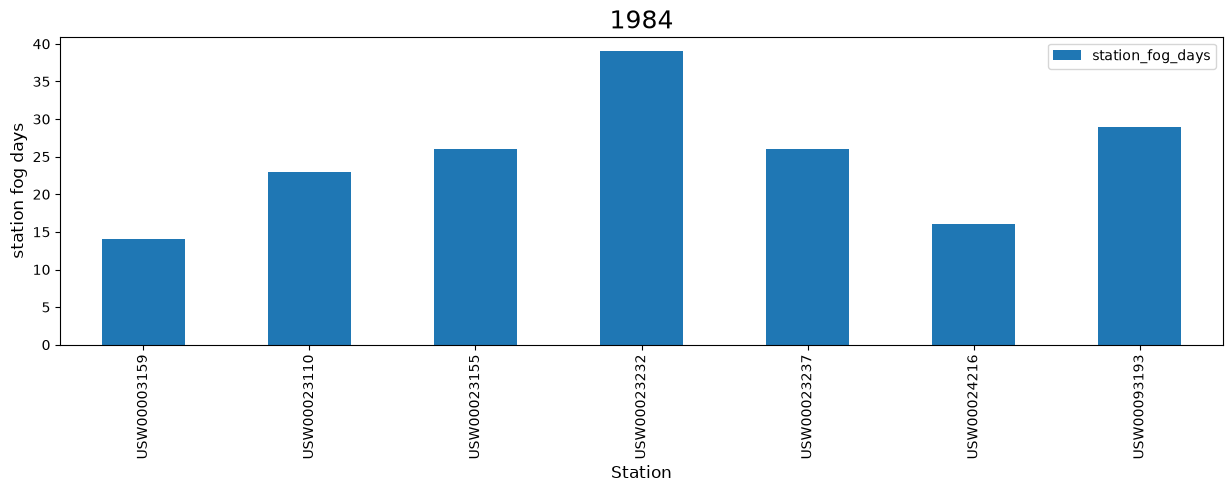

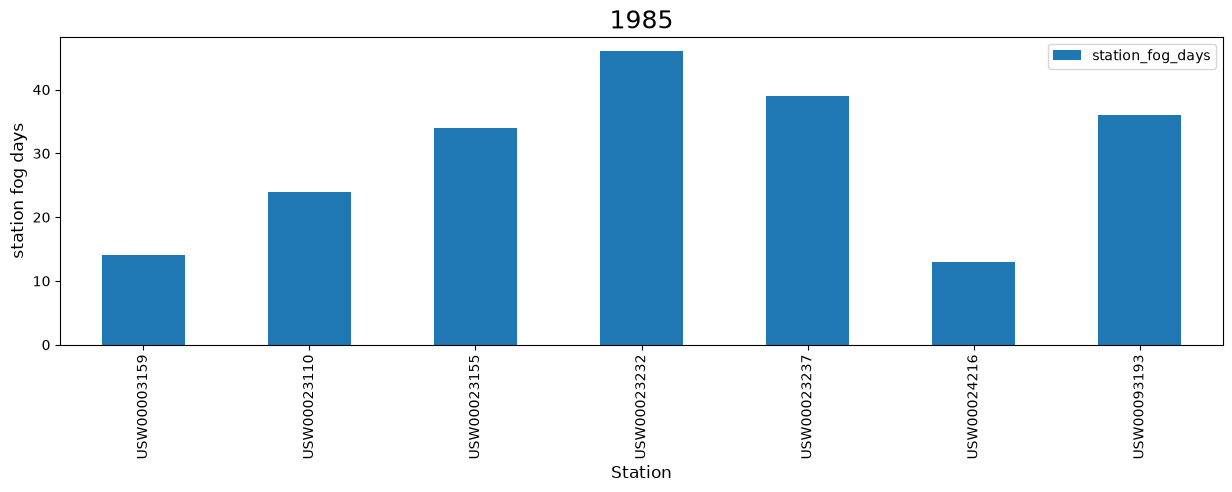

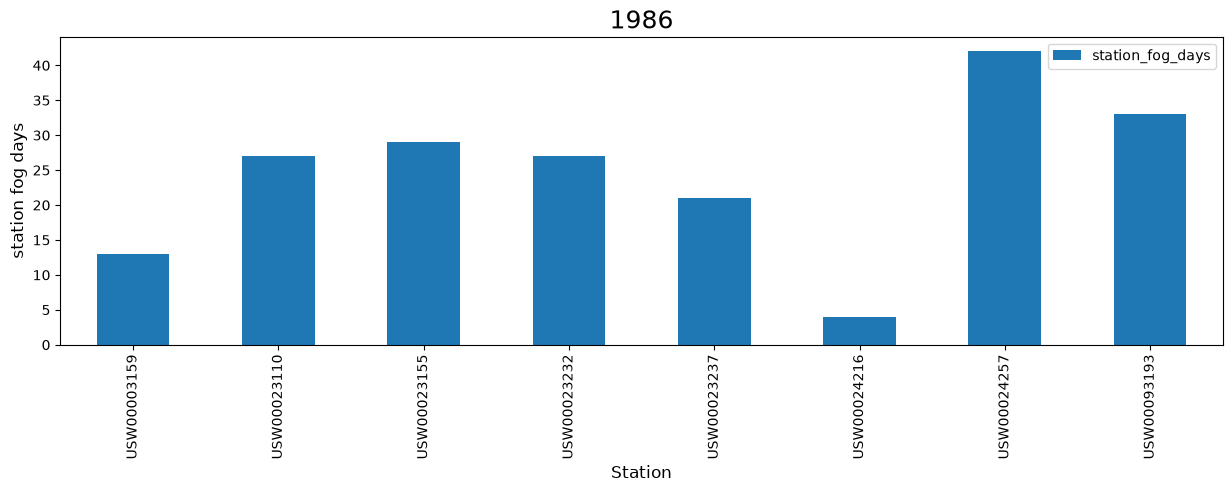

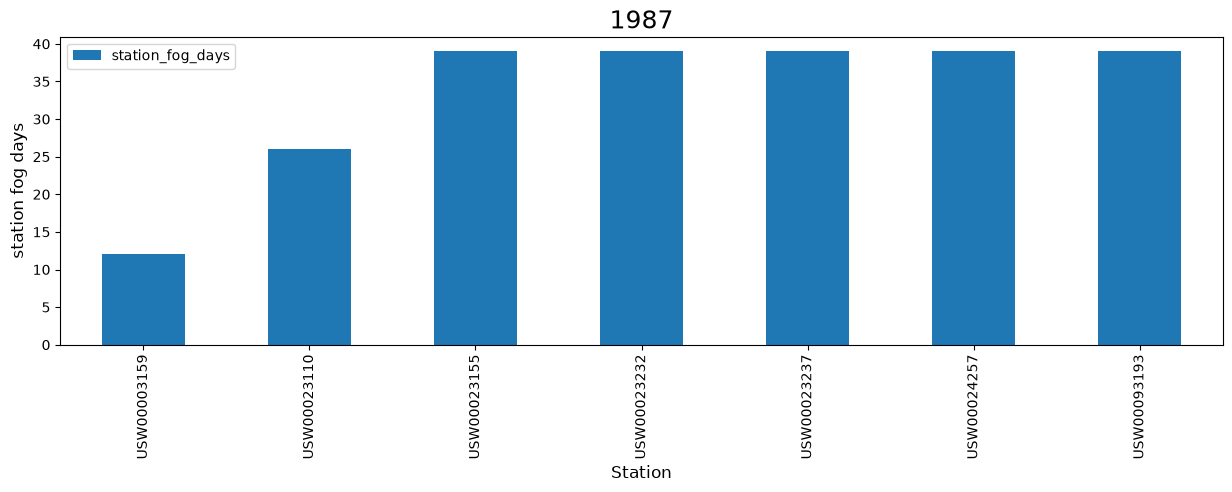

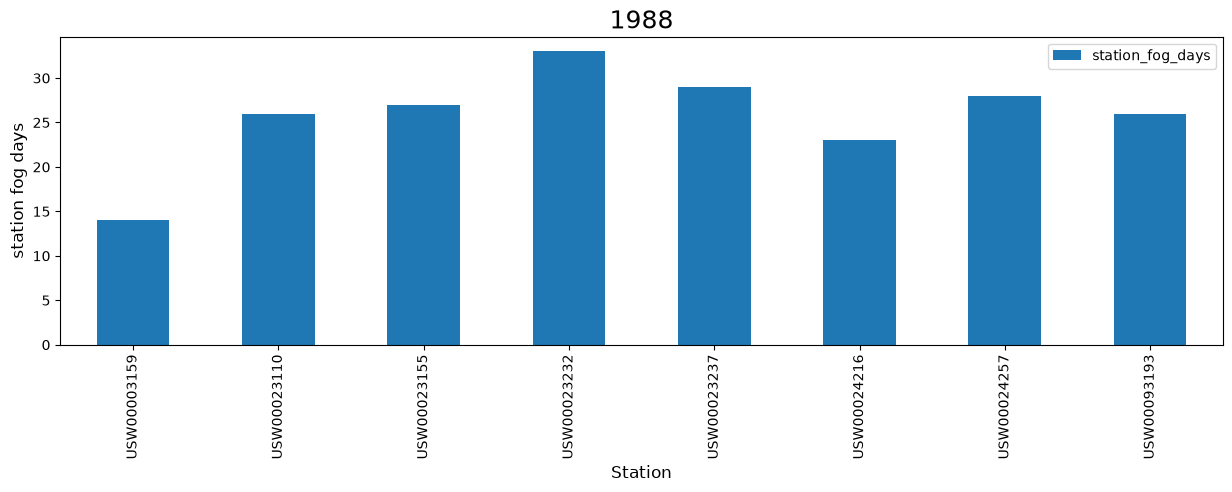

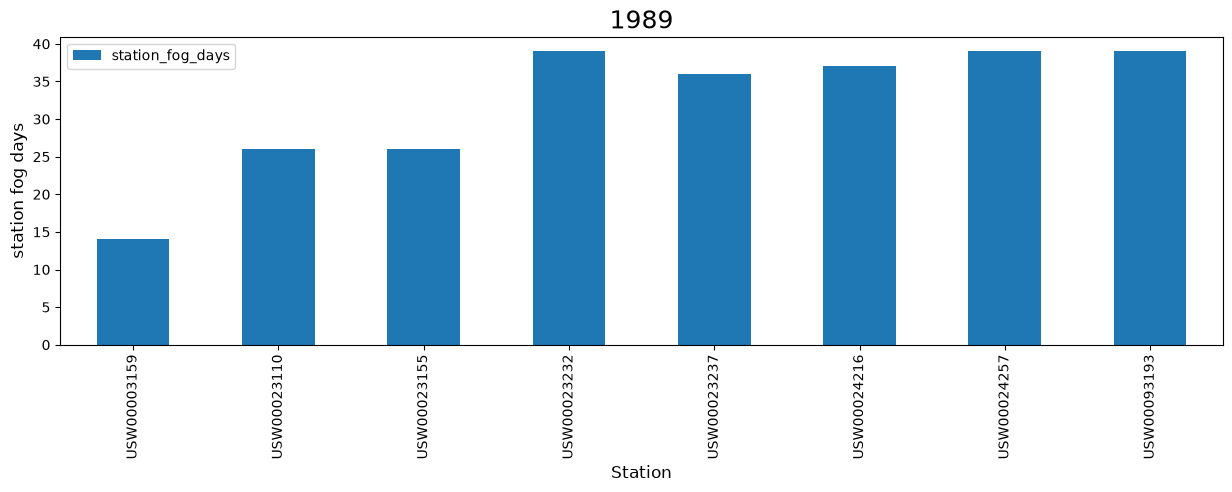

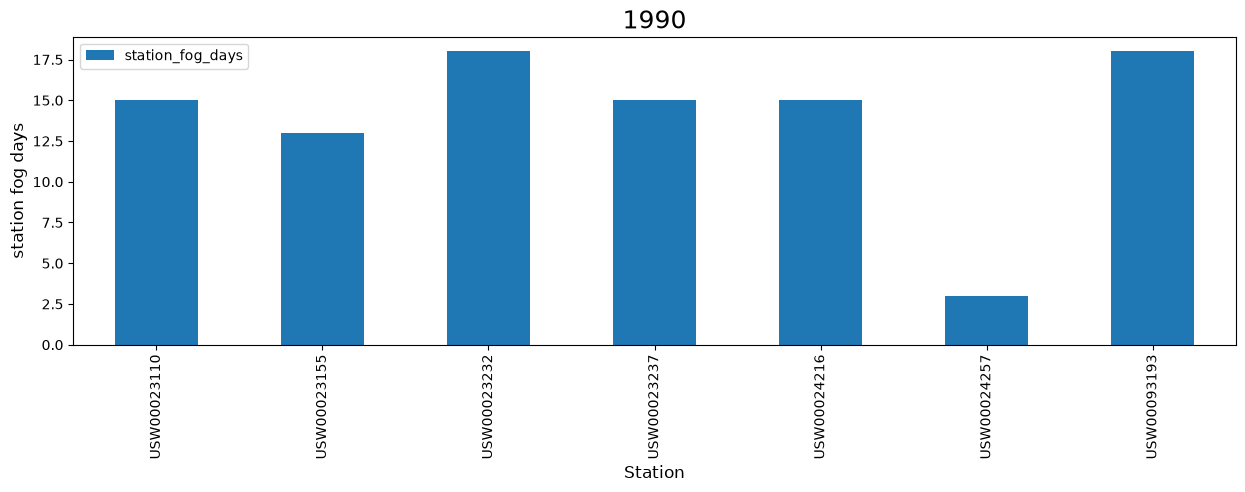

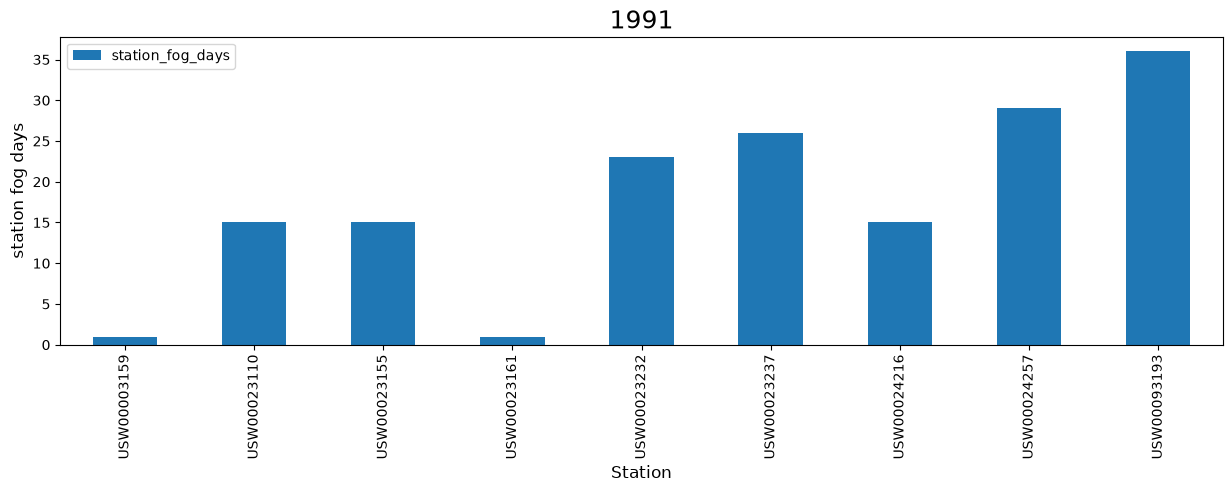

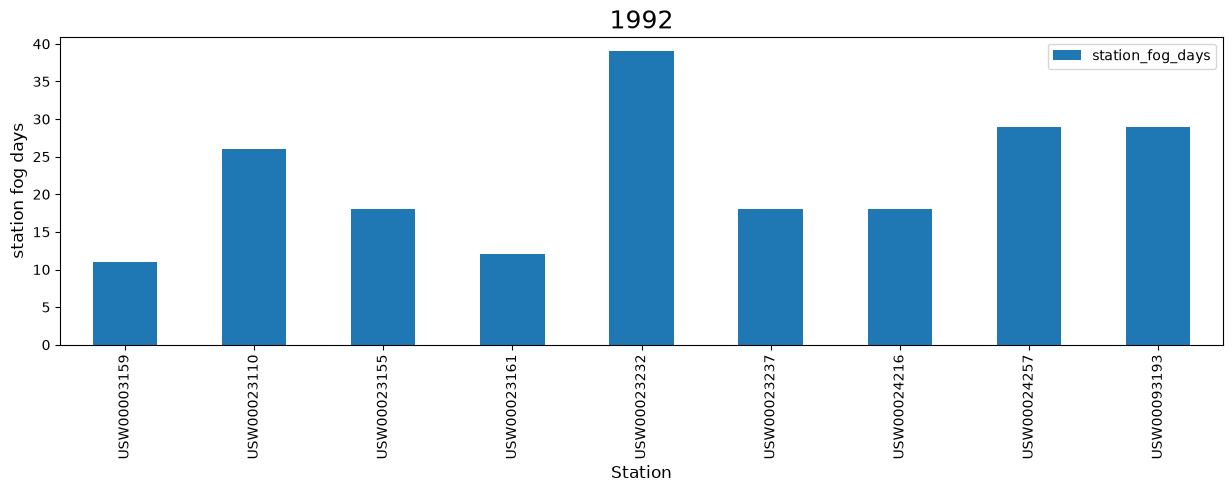

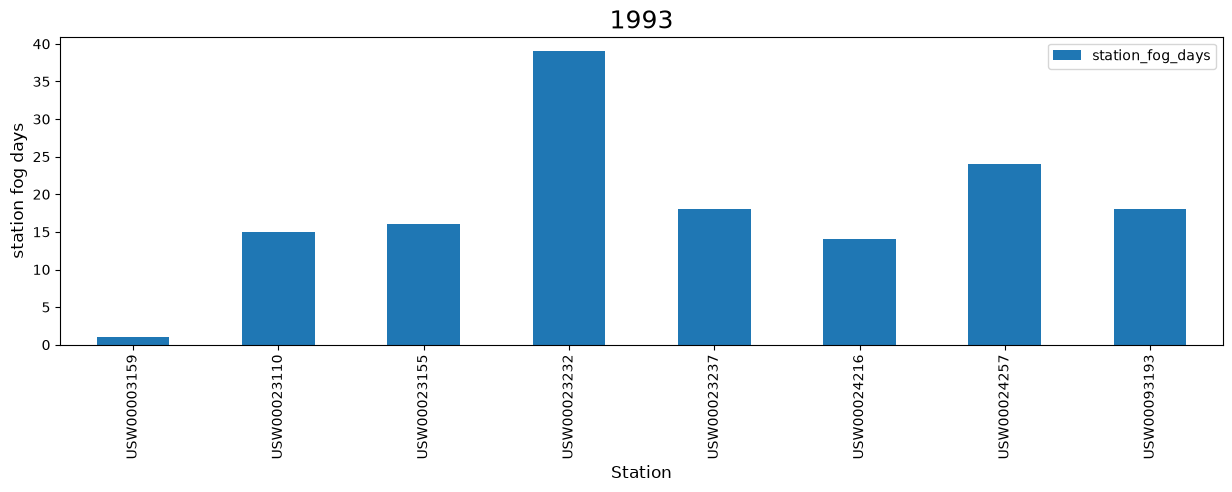

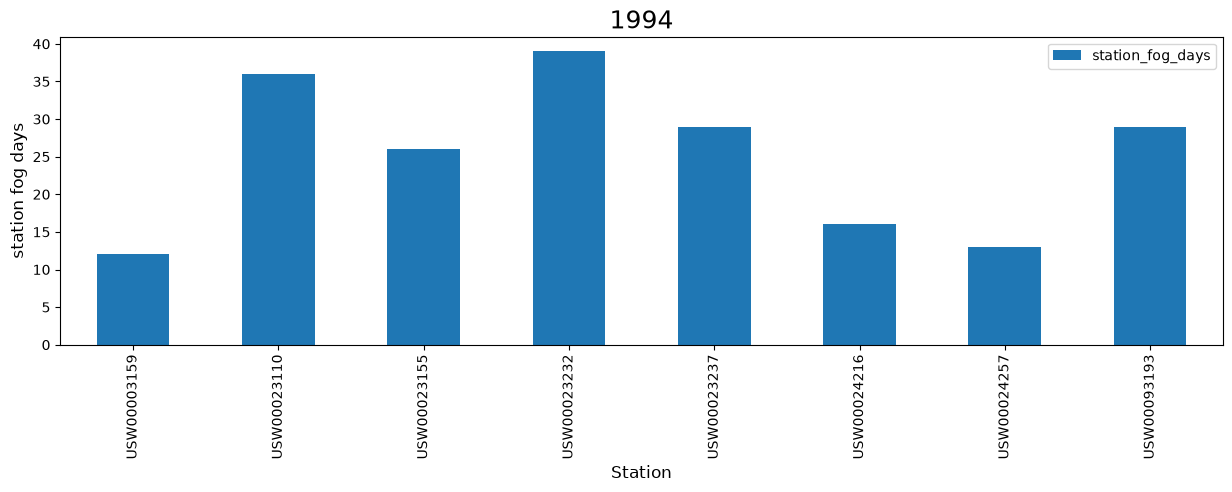

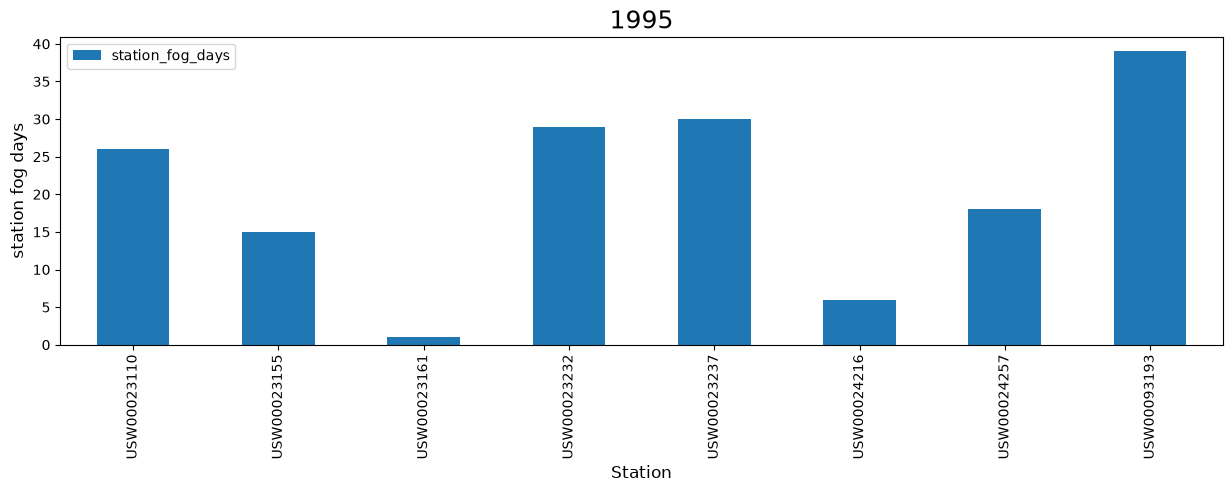

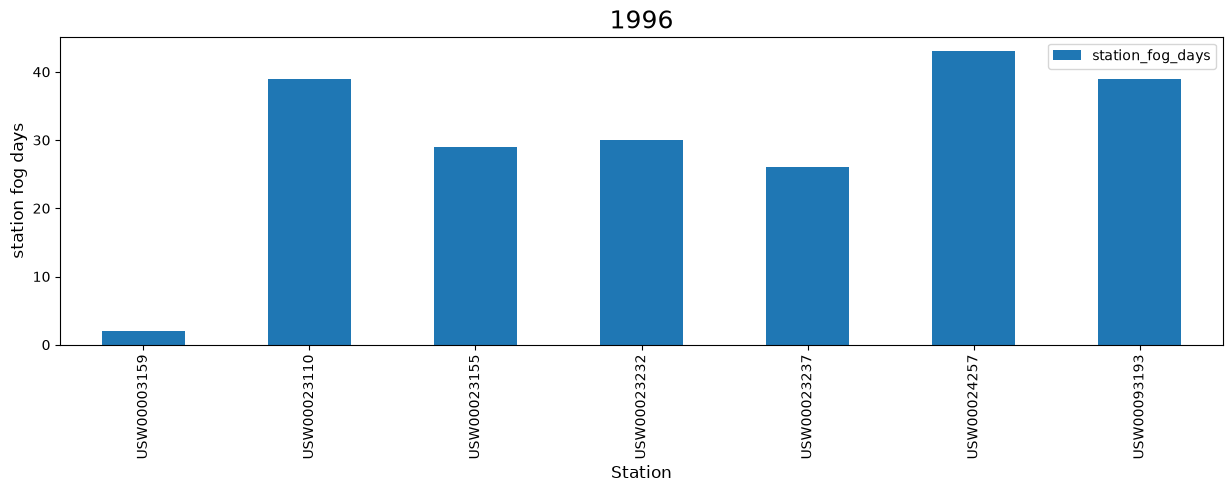

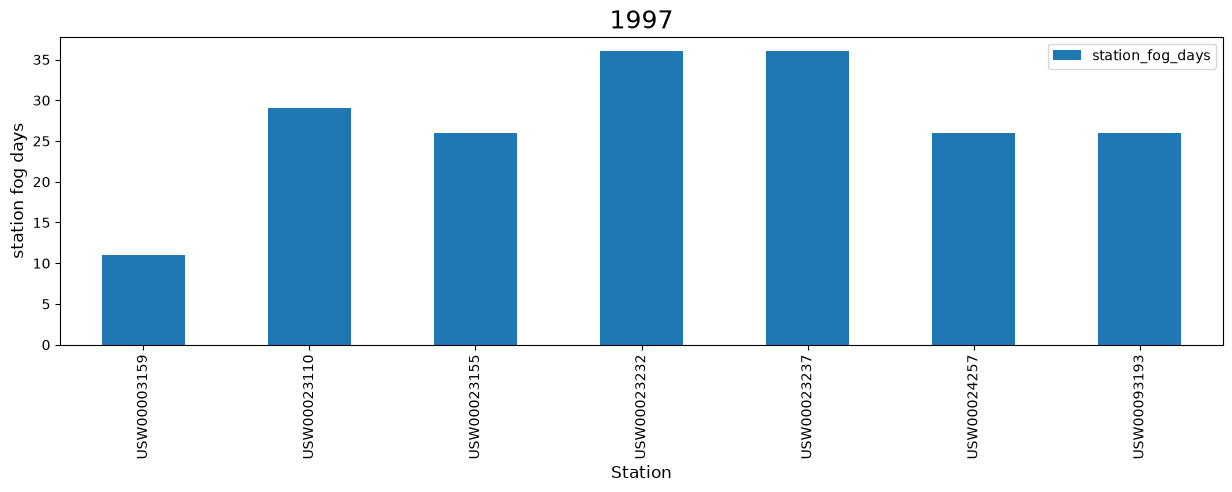

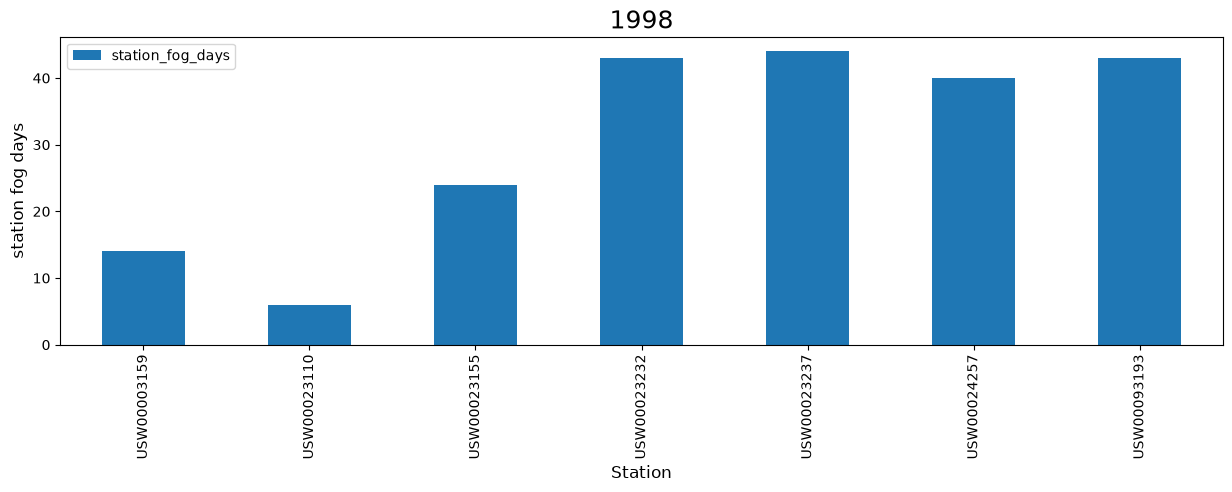

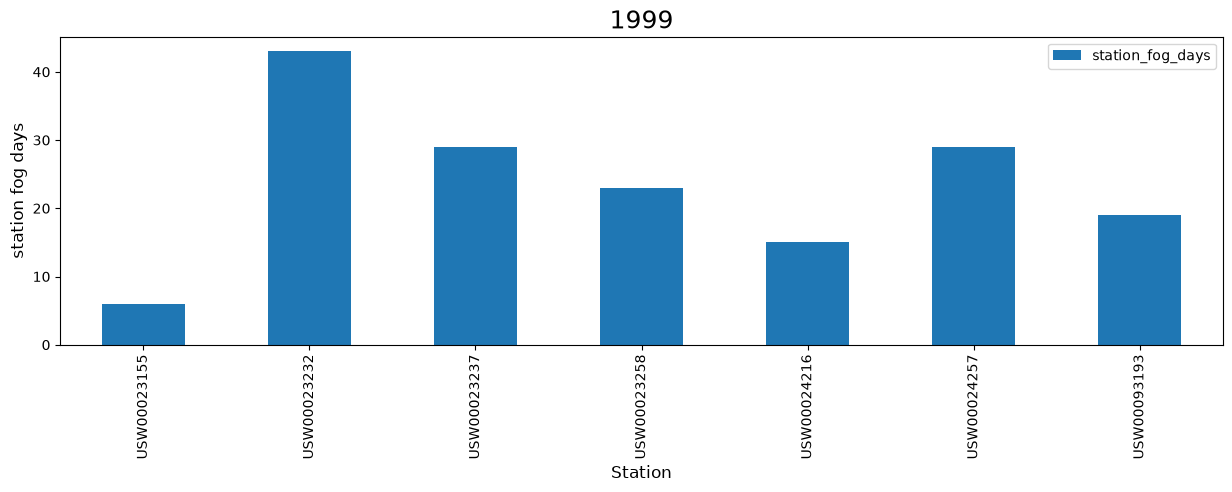

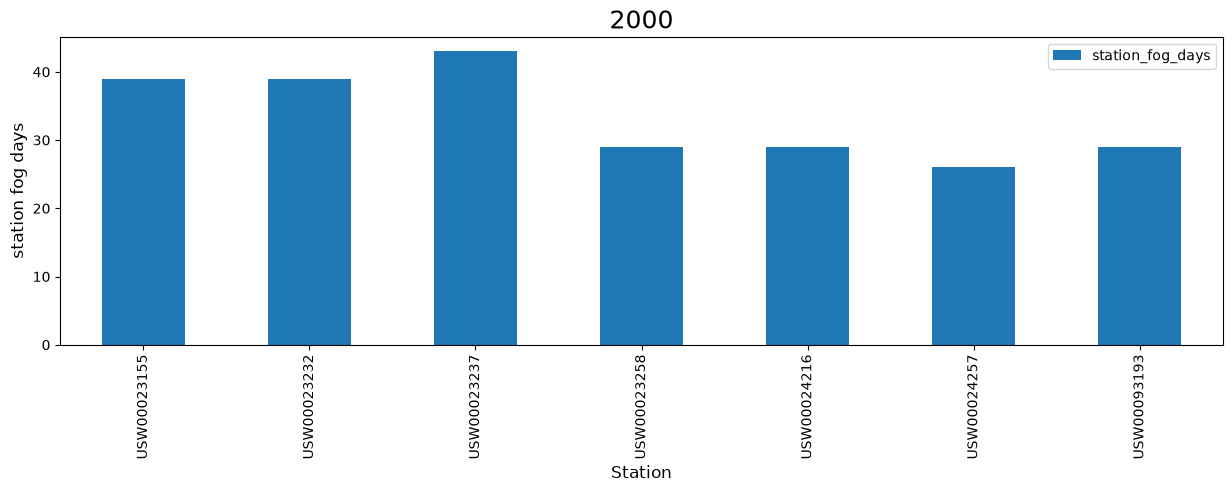

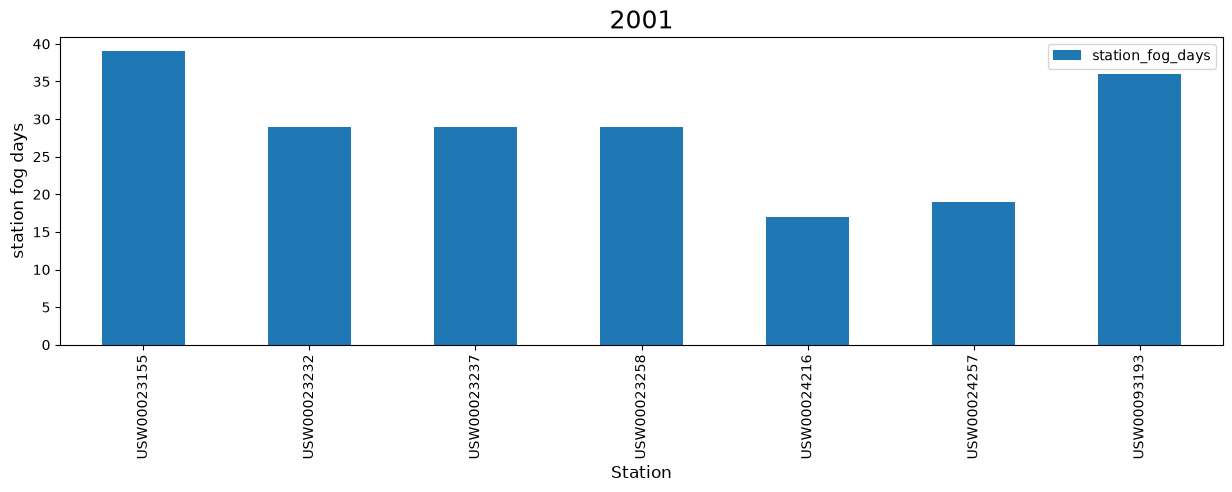

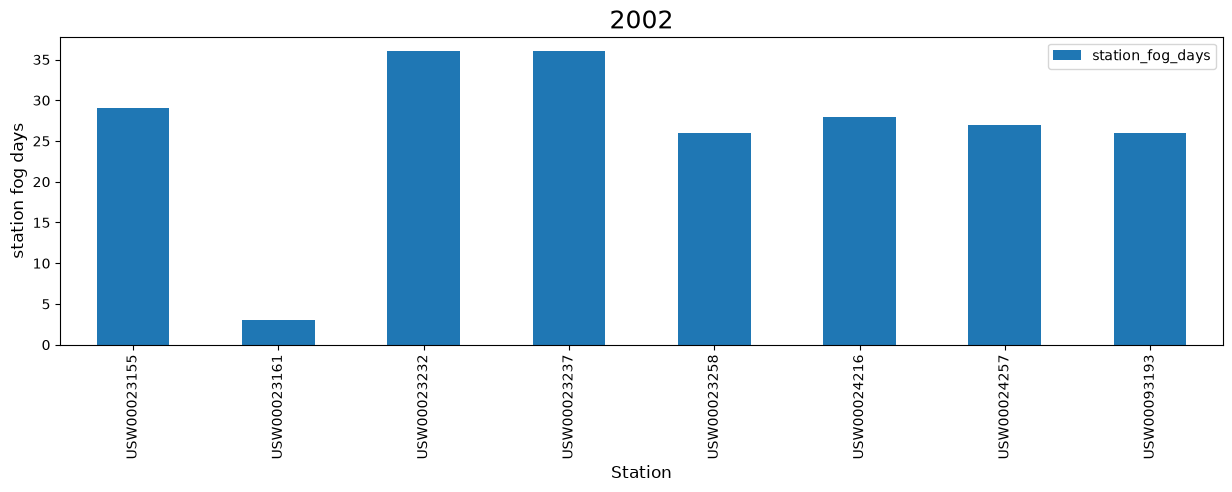

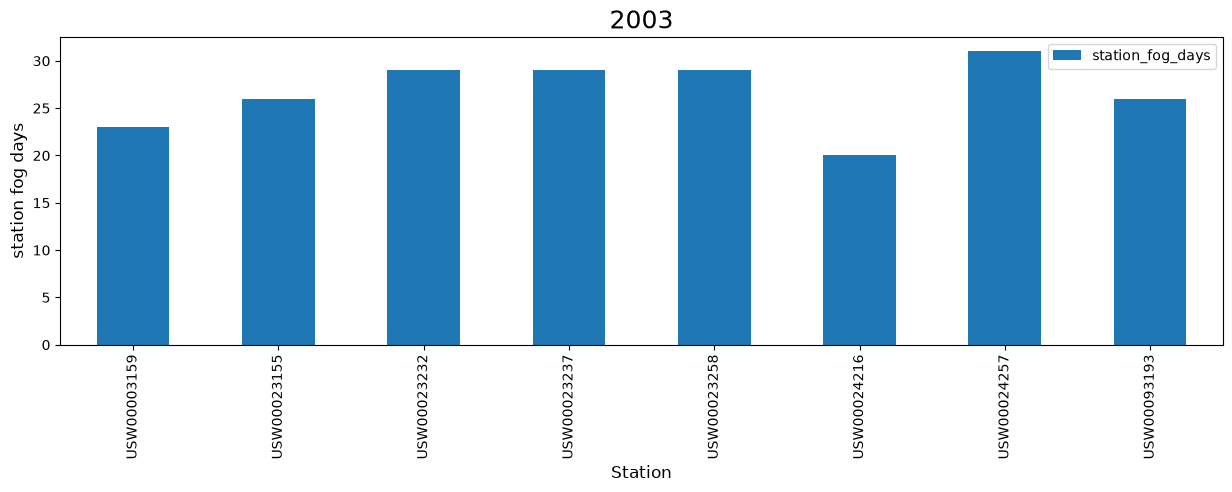

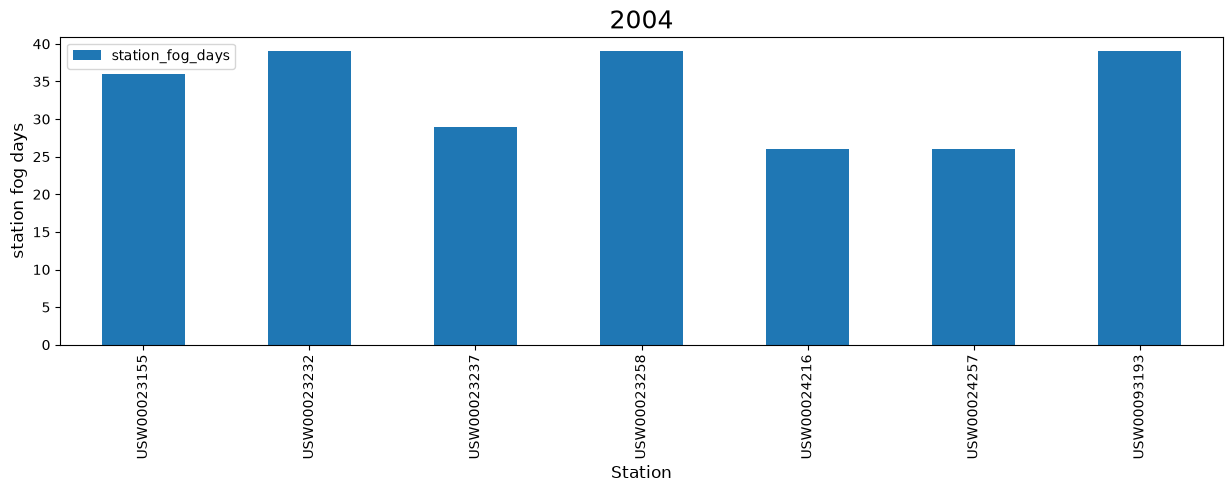

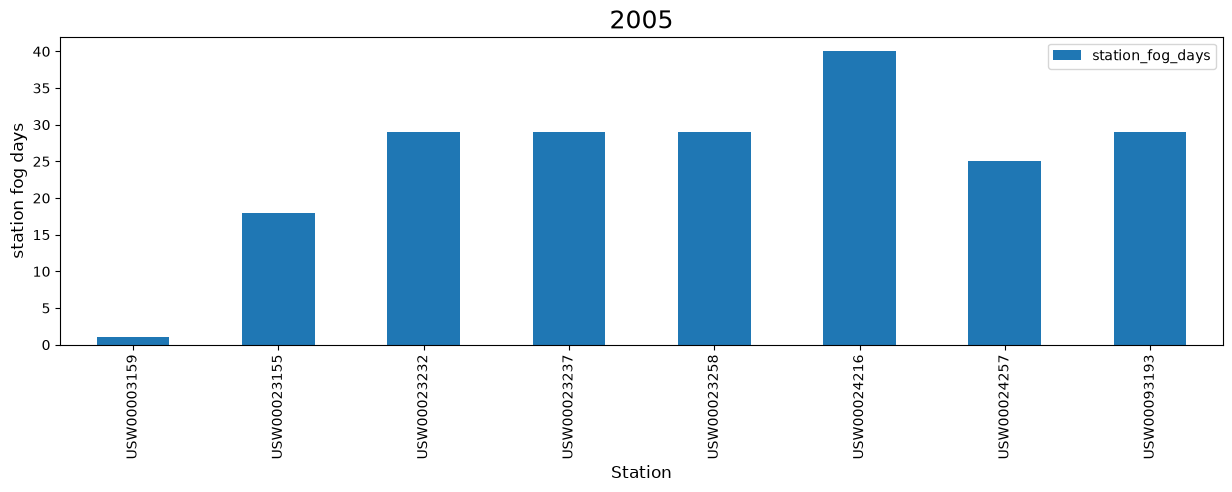

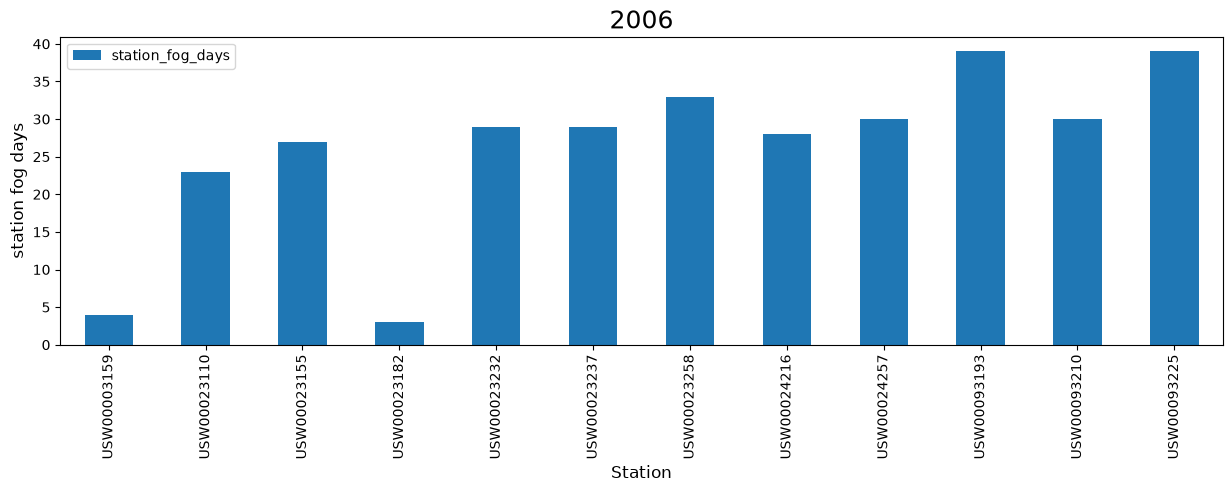

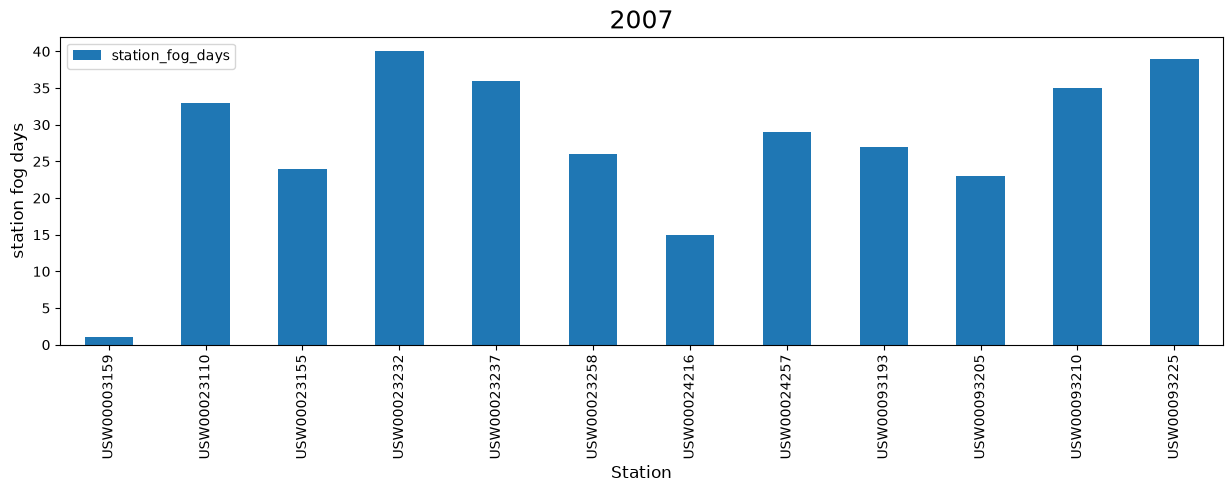

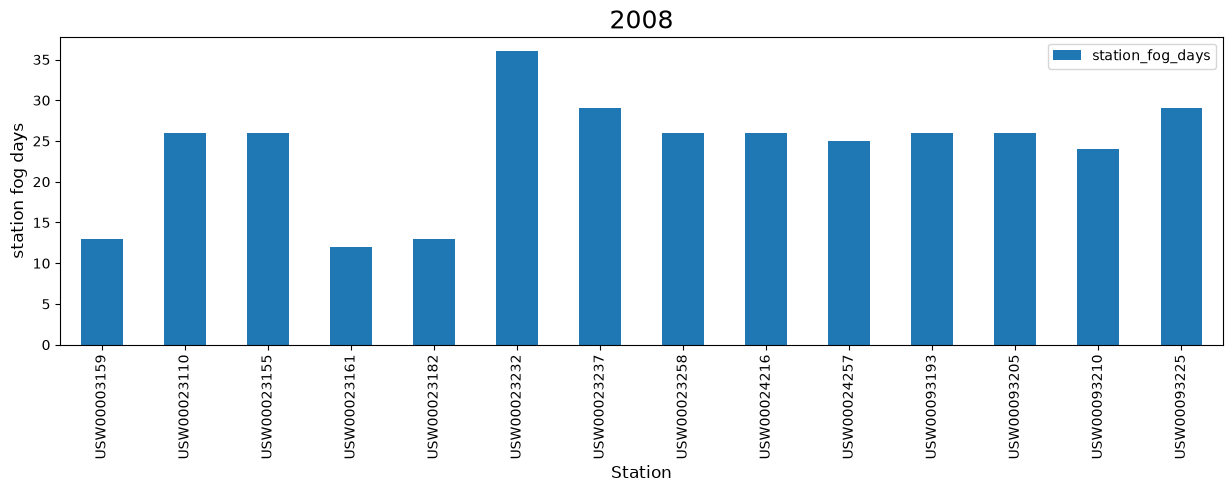

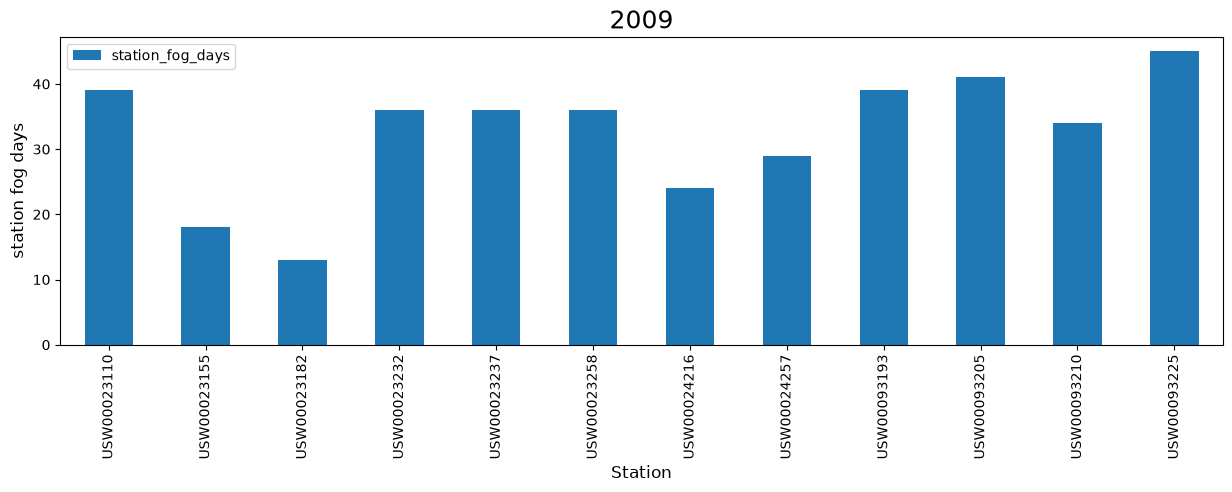

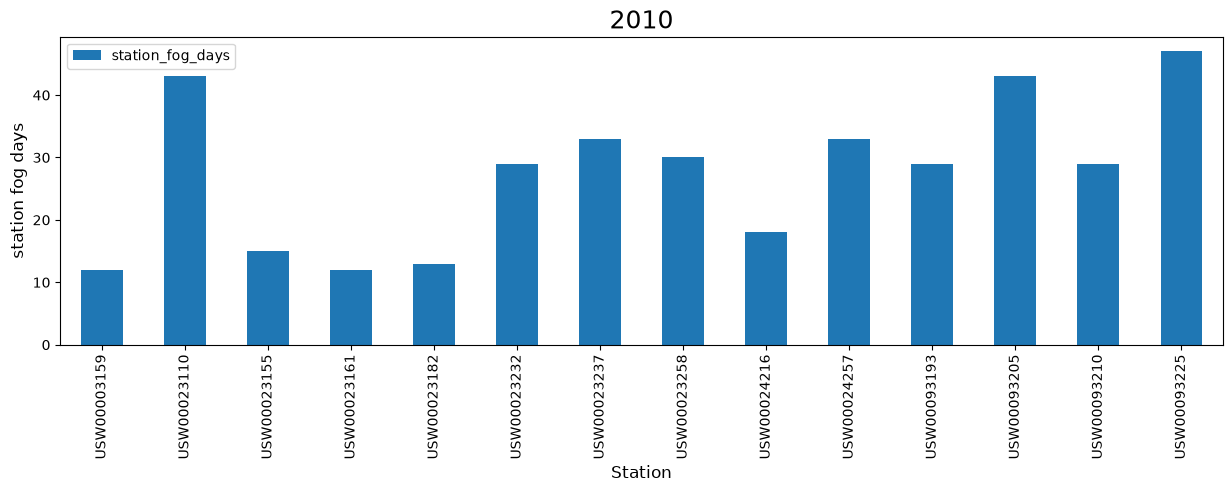

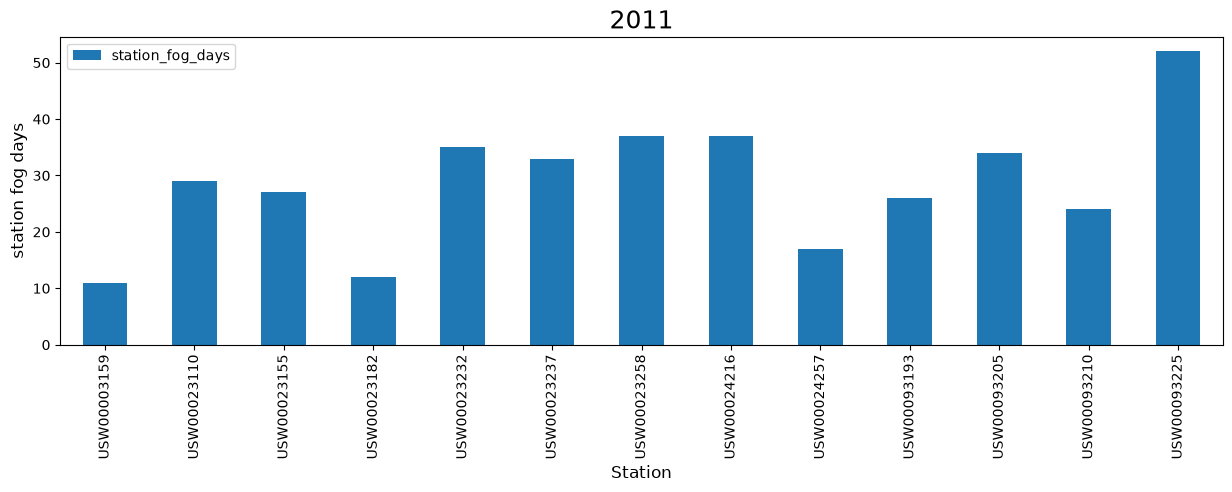

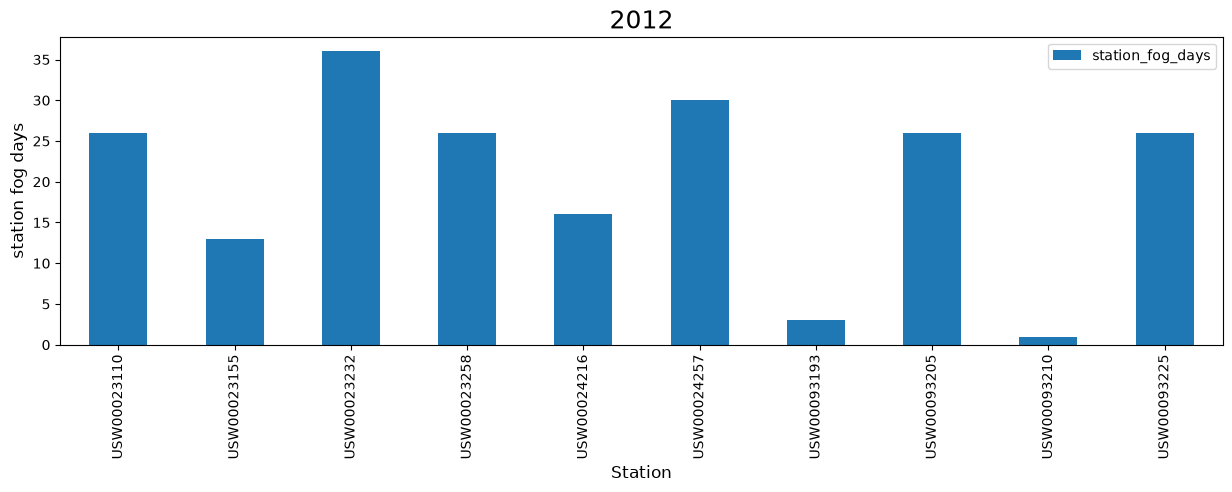

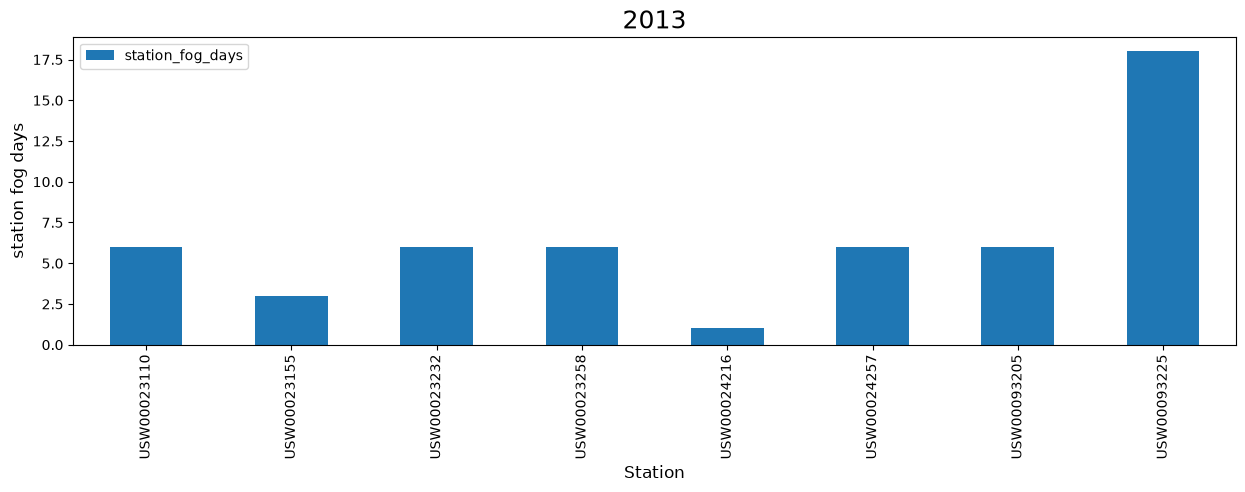

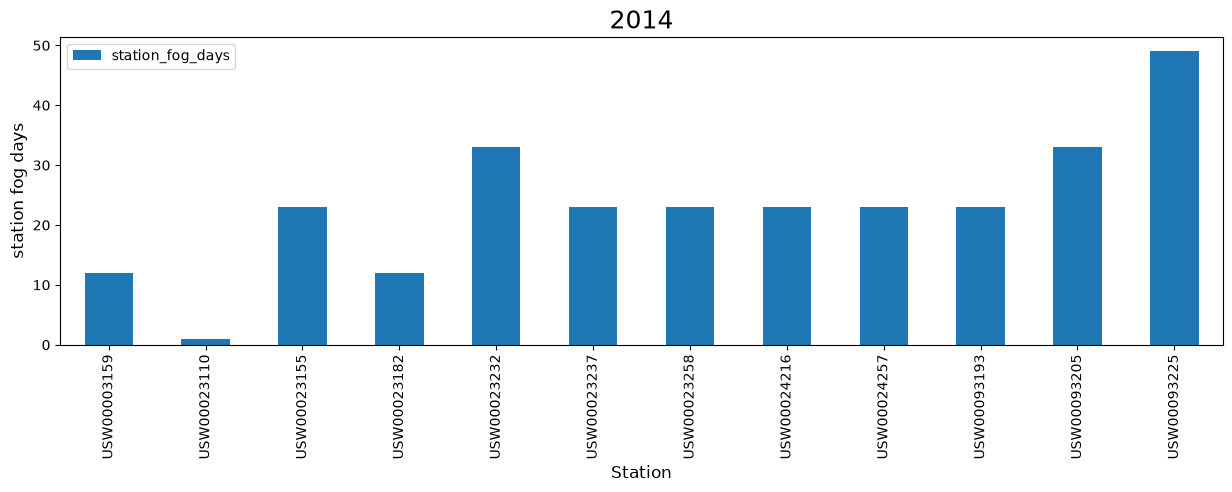

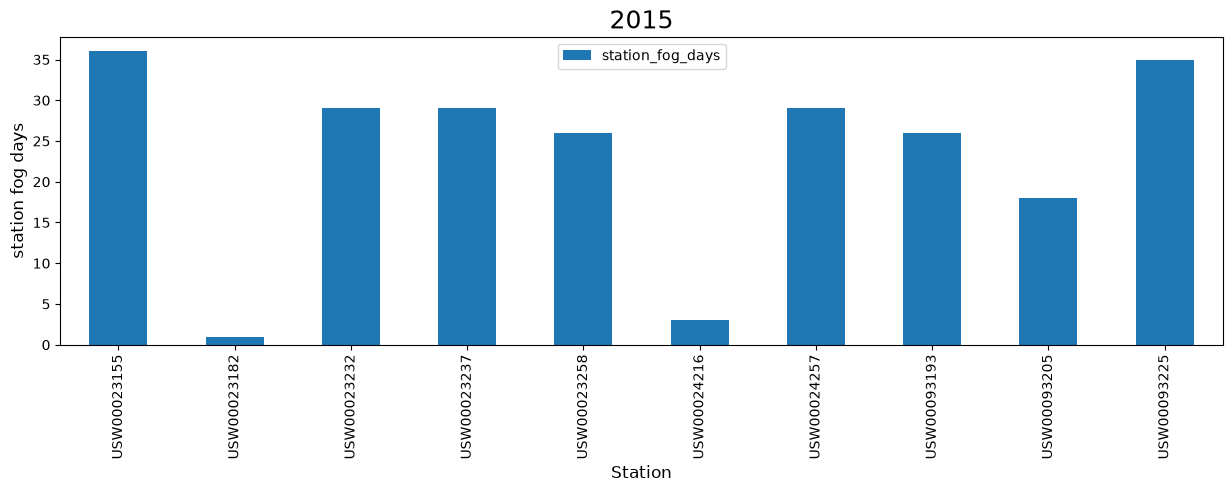

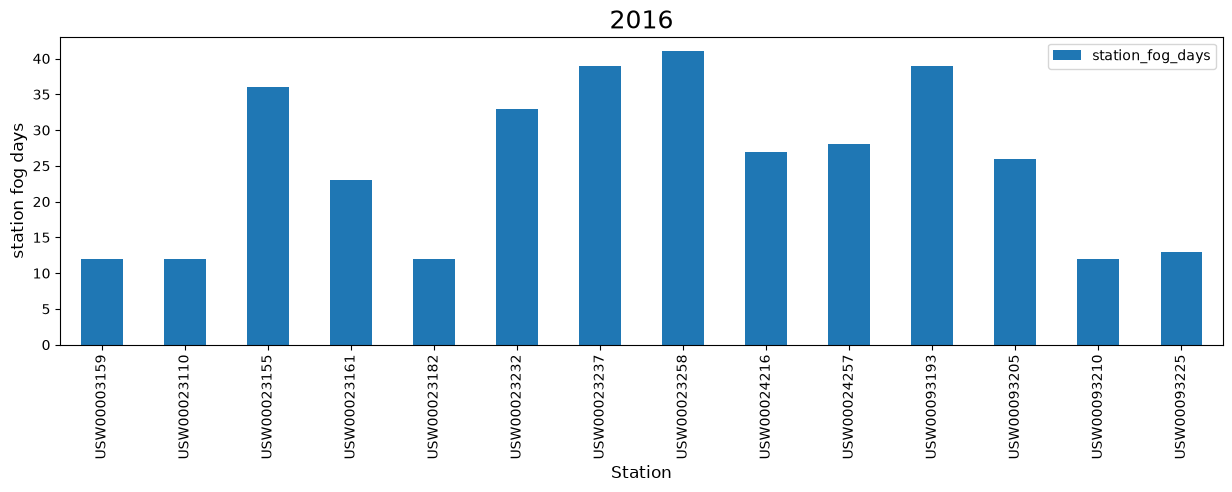

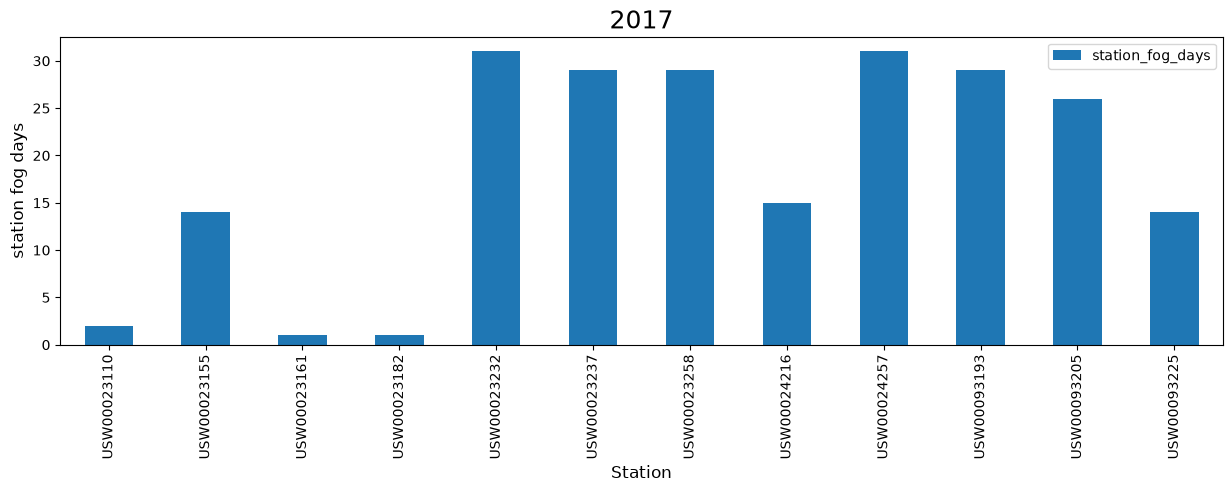

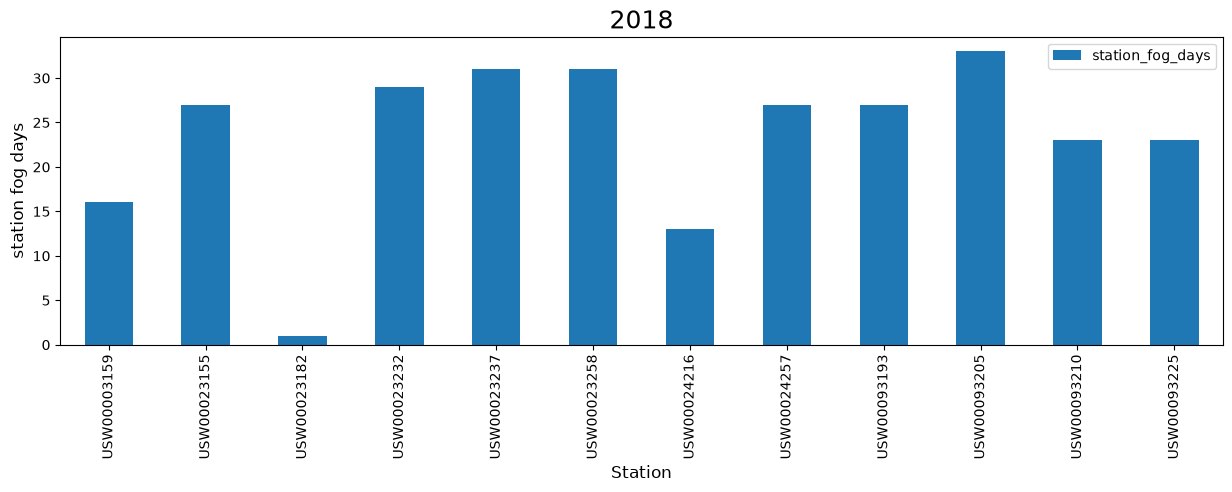

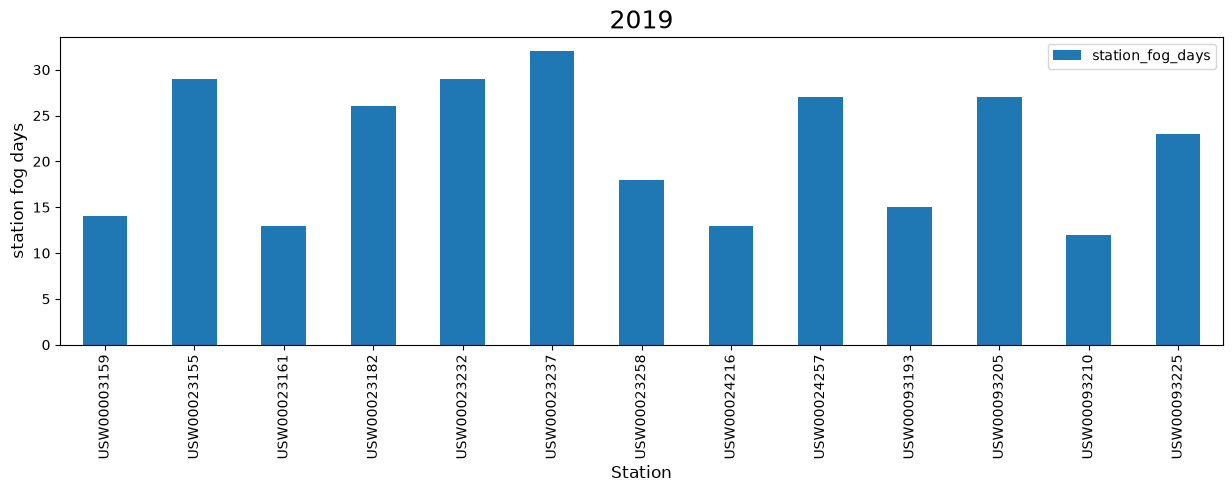

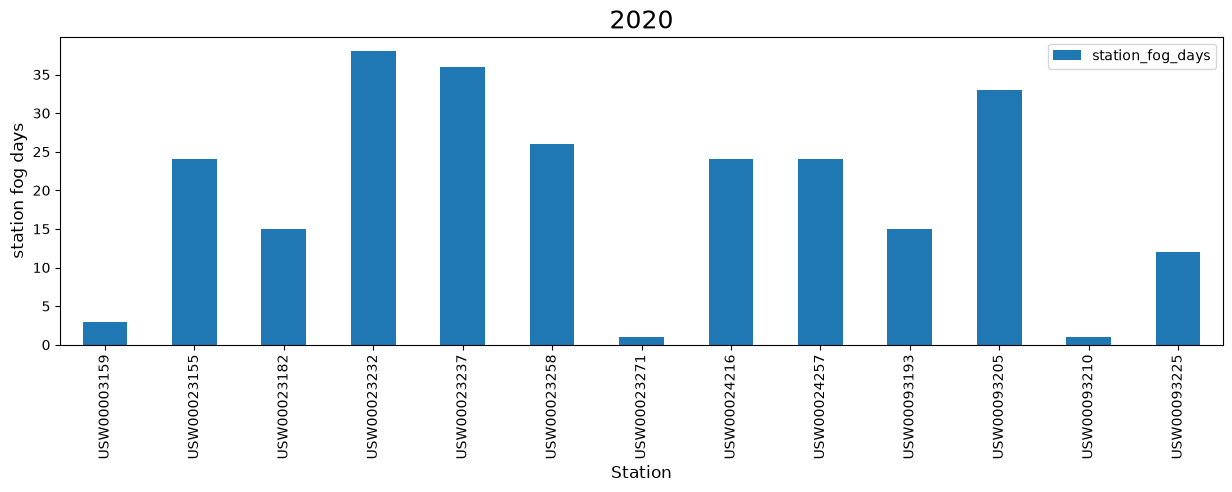

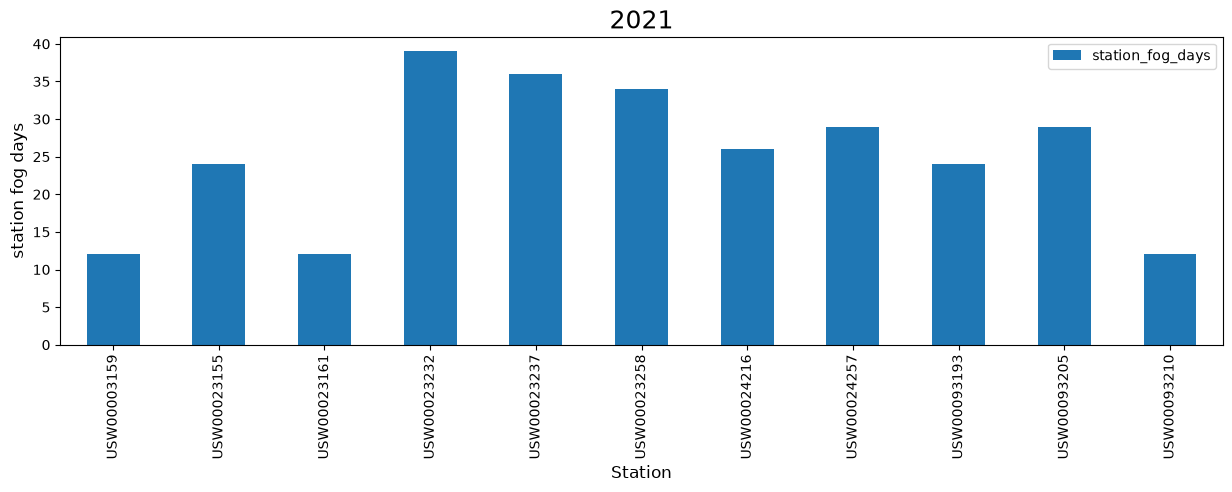

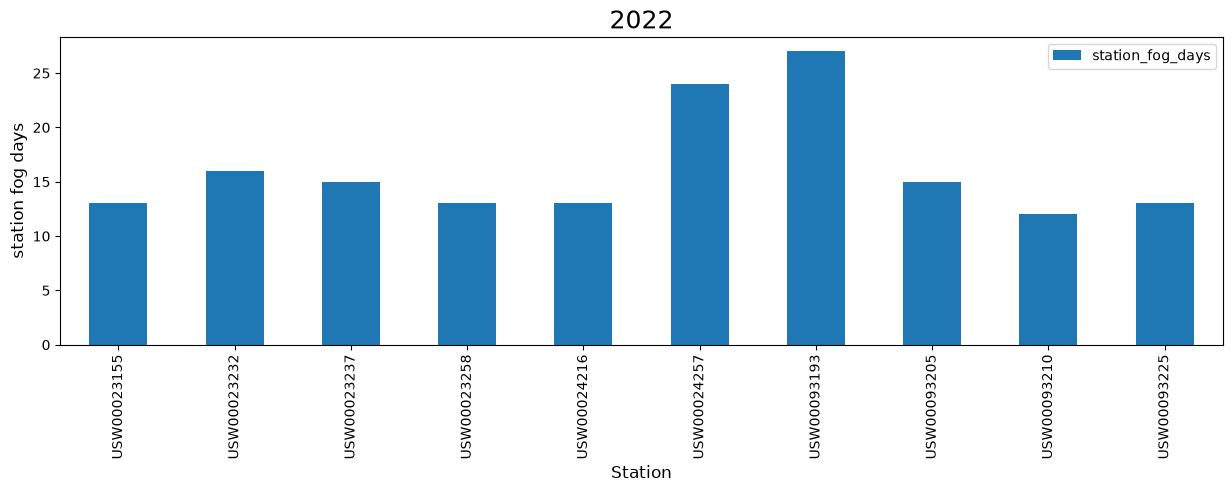

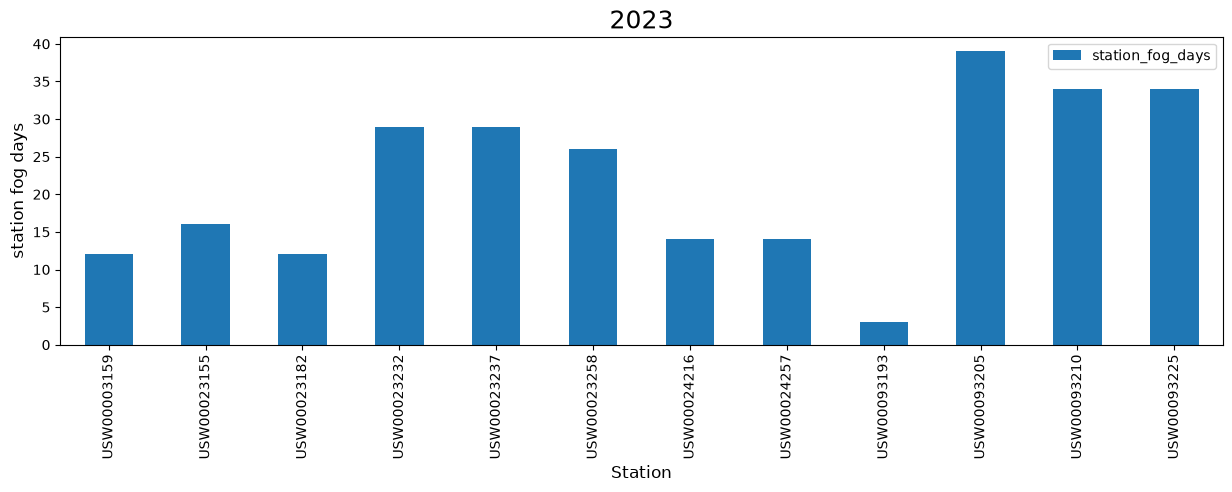

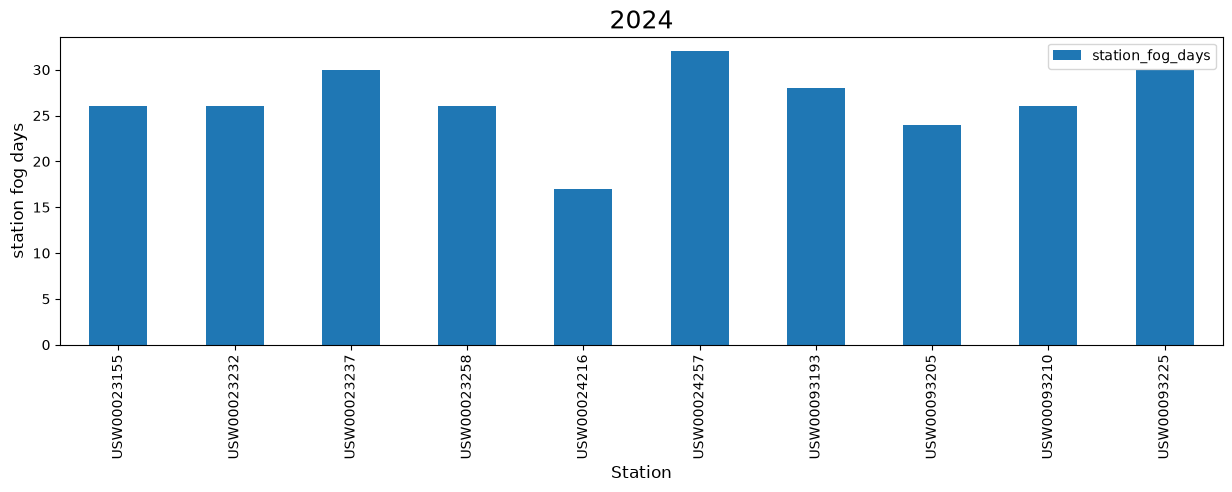

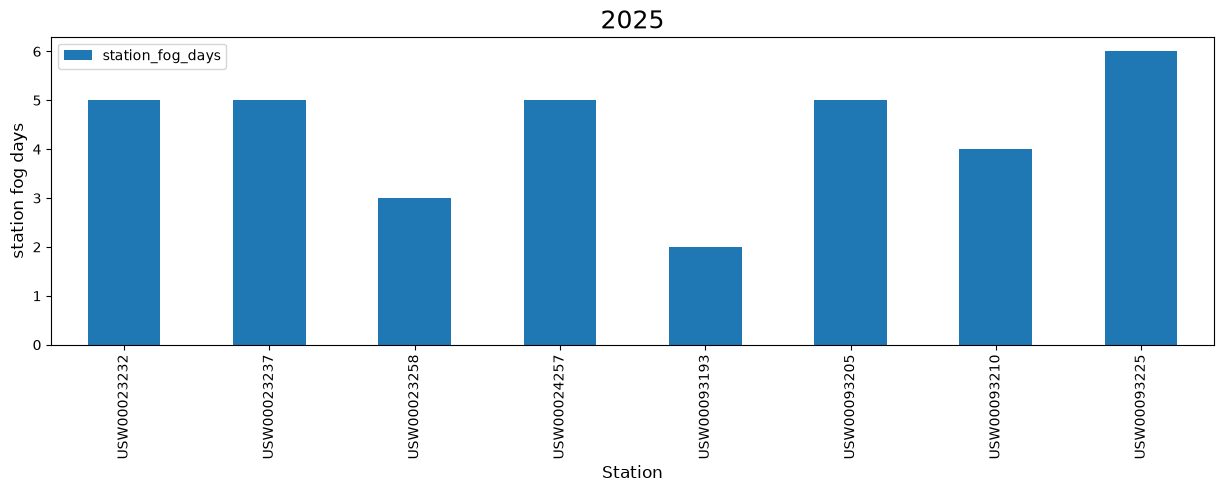

In [20]:
# determine total fog days for each station per year and plot per station
for i in years_considered:
    CVtotal_fog_rows.loc[(CVtotal_fog_rows['year'] == i)].plot(x='STATION',y="station_fog_days", figsize=(15,4), kind = 'bar')
    plt.title(i, fontsize=18) #Labeling title
    plt.xlabel('Station', fontsize=12) #Labeling x-axis 
    plt.ylabel('station fog days', fontsize=12) #Labeling y-axis 

plt.show()